# GIA - APRNS

## Sesión: Flujos

Esta sesión de laboratorio vamos a probar los diferentes modelos de flujos que hemos visto en teoría.

Como recordaréis estos modelos permiten transformar una distribución de probabilidad en otra a partir de una función de transformación que es invertible (aparte de derivable y monótona).

Esta función de transformación permite estimación y muestreo de una distribución compleja a partir de su correspondencia con una distribución más simple. En el caso de que partamos de la distribución gausiana estos modelos se llaman flujos normalizantes.


Para los ejemplos de modelos de flujos usaremos la libreria `normflows`. Antes de ejecutar el notebook deberemos instalarla descomentando la siguiente celda. Una vez instalada deberemos **reiniciar** el notebook para que este disponible (en colab no debería hacer falta)

<font color='red' size=4> Antes de inciar el notebook descarga el modelo preentenado que hay para la sesion y subelo a colab</font>


In [2]:
!pip install --quiet normflows

In [3]:
from torch.optim import lr_scheduler
import torch

import normflows as nf

from matplotlib import pyplot as plt

from tqdm import tqdm
import numpy as np
from sklearn.datasets import make_moons

from time import time
from datetime import timedelta
init_time = time()

device = torch.device("cuda")

torch.__version__, torch.cuda.is_available(), device

('2.9.1+cu128', True, device(type='cuda'))

In [4]:
!nvidia-smi

Mon Dec 22 17:02:25 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.95.05              Driver Version: 580.95.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4070 ...    Off |   00000000:01:00.0  On |                  N/A |
|  0%   34C    P8              9W /  220W |    3957MiB /  12282MiB |     11%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Funciones auxiliares

Esta función realiza el entrenamiento de un modelo y retorna el valor de la función de pérdida de todo el entrenamiento. La función de pérdida de todos los modelos es la divergencia de Kullback-Leibler

Solo utiliza una muestra de entrenamiento, si queréis que se use una muestra de test para poder usarla para monitorizar la sobre especialización o usarla para terminar el entrenamiento deberéis modificar la función.

In [5]:
# Training loop para los diferentes modelos
def train_loop(model, optimizer, scheduler, dataloader, epochs, conditional=False):
    hist_loss = []
    pbar = tqdm(range(epochs))
    for epoch in pbar:
        running_loss = 0.0
        for i, data in enumerate(dataloader):
            optimizer.zero_grad()

            # calcula la pérdida dependiendo de si es condicional o no
            if not conditional:
                loss = model.forward_kld(data.to(device))
            else:
                loss = model.forward_kld(data[0].to(device), data[1].to(device))

            # si la pérdida no es nan o inf, hace el backpropagation
            if ~(torch.isnan(loss) | torch.isinf(loss)):
                loss.backward()
                optimizer.step()

            # guarda la pérdida
            running_loss += loss.item()

        if scheduler is not None:
            scheduler.step()
            lr = f'lr: {scheduler.get_last_lr()[0]:.4E}'
        else:
            lr = ''

        hist_loss.append(running_loss / i)
        pbar.set_description(f'loss: {running_loss / i:3.4f}:{lr}')

    return hist_loss

In [6]:
# Cambiar para reducir o aumentar el tiempo de entrenamiento
epochs = 500

# Once in a blue moon

Como ejemplo sencillo comprobaremos que se puede transformar un conjunto de datos que tiene una distribución en otra más sencilla (gausiana) y a partir de ese modelo podemos generar muestras usando la transformación en sentido inverso.

Para ello generaremos un conjunto de muestras del dataset two moons que consiste en dos lunas crecientes imbricadas (no linealmente separables), por lo que tenemos una distribución bimodal que modelizaremos con una gausiana unimodal.

In [7]:
X,_ = make_moons(2048, noise=0.1)

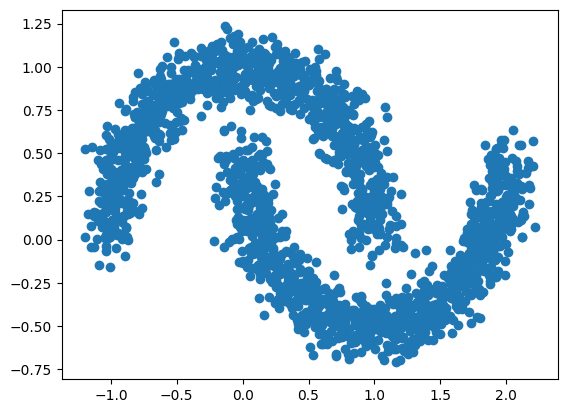

In [8]:
plt.scatter(X[:,0], X[:,1]);

Definimos el flujo que tiene como distribución base una gausiana bidimensional ($N(0,1)$) y usamos una secuencia de transformaciones compuestas por flujos afines y permutaciones. Los flujos afines calculan traslaciones y escalados usando un MLP de dos capas. Este flujo sigue la transformación de RealNVP aplicando la transformación a la mitad de las variables (una variable) y dejando tal cual la otra mitad (una variable). La capa de permutación intercambia las variables que se transforman.

Se elige un número de capas suficiente para que el flujo tenga expresividad.

In [9]:
base = nf.distributions.base.DiagGaussian(2)

# Definir la lista de capas del flow
num_layers = 5
flows = []
for i in range(num_layers):
    # Los parametros del Affine Coupling Flow se calculan con una red neuronal
    # Cada capa transforma la mitad de los parametros y calcula la traslacion y el escalado
    # El tamaño de entrada de la red es #variables/2 y la salida es el escalado y traslacion
    param_map = nf.nets.MLP([1, 32, 32, 2], init_zeros=True)
    # Capa de Affine Coupling
    flows.append(nf.flows.AffineCouplingBlock(param_map))
    # Capa que intercambia las variables
    flows.append(nf.flows.Permute(2, mode='swap'))

# Definimos el flujo a partir de la distribucion base y las capas del flujo
model_2m = nf.NormalizingFlow(base, flows).to(device)

Creamos un data loader para los datos

In [10]:
moons_dl = torch.utils.data.DataLoader(torch.tensor(X).type(torch.float32), batch_size=128)

Optimizamos el modelo por un numero suficiente de epochs

loss: 1.1698:lr: 6.0638E-04: 100%|██████████| 500/500 [00:19<00:00, 25.95it/s]


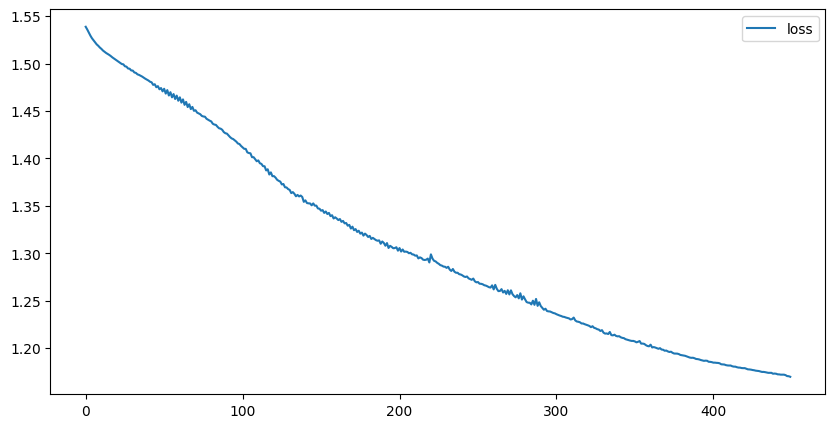

In [11]:
optimizer = torch.optim.Adamax(model_2m.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = lr_scheduler.MultiplicativeLR(optimizer, lr_lambda=lambda _: 0.999)

loss_hist = train_loop(model_2m, optimizer, scheduler, moons_dl, epochs)

plt.figure(figsize=(10, 5))
plt.plot(loss_hist[epochs//10:], label='loss')
plt.legend()
plt.show()

Una vez entrenado el modelo podemos usarlo para obtener muestras. Podemos ver que el ajuste no es perfecto, pero sí obtenemos dos modalidades que siguen la distribución original. Fijaos que para muestrear estamos obteniendo una muestra gausiana y simplemente la estamos transformado mediante el modelo usando el hecho de que es una función invertible para obtener la muestra de la distribución original.

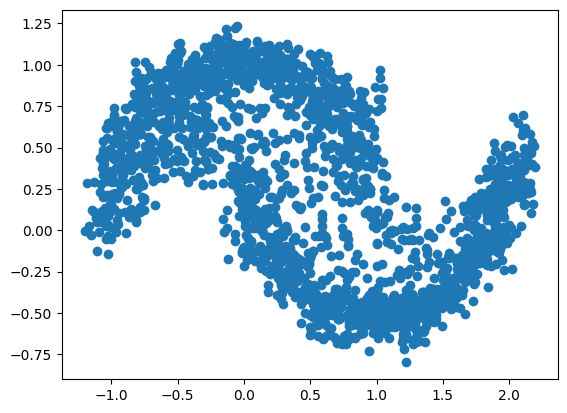

In [12]:
samples = model_2m.sample(num_samples=2048)[0].cpu().detach().numpy()
plt.scatter(samples[:,0], samples[:,1]);

Si queremos podemos partir de una distribución base que se parezca más a la distribución objetivo, por ejemplo podemos usar una mezcla de gausianas que sea bimodal para hacer más sencilla la correspondencia.

In [13]:
# Definimos una mezcla de gausianas bimodal
baseGM = nf.distributions.base.GaussianMixture(2,2, loc=np.array([[-2,0],[2,0]], dtype=np.float32),scale=np.array([[0.3,0.3],[0.3,0.3]], dtype=np.float32))

Definimos el nuevo modelo con el mismo flujo (queda como ejercicio para el lector el probar si un flujo más pequeño es ahora suficiente para obtener un buen resultado)

In [14]:
model_2m_GM = nf.NormalizingFlow(baseGM, flows).to(device)

Optimizamos el nuevo modelo

loss: 1.1258:lr: 6.0638E-04: 100%|██████████| 500/500 [00:20<00:00, 24.37it/s]


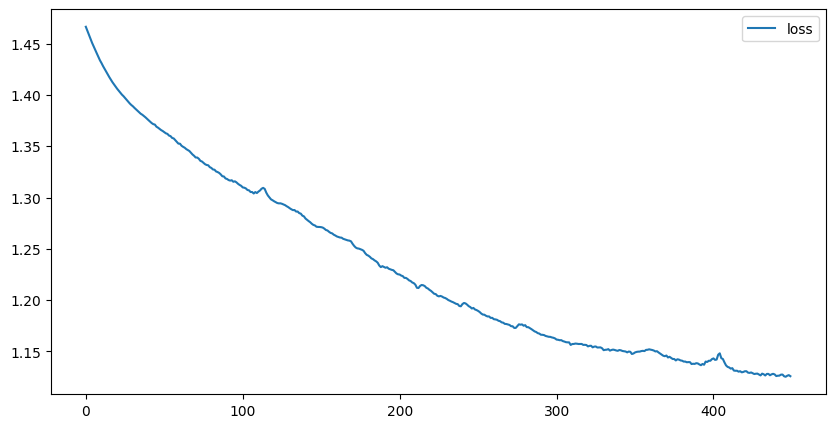

In [15]:
optimizer = torch.optim.Adamax(model_2m_GM.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = lr_scheduler.MultiplicativeLR(optimizer, lr_lambda=lambda _: 0.999)
epochs = 500
loss_hist = train_loop(model_2m_GM, optimizer, scheduler, moons_dl, epochs)

plt.figure(figsize=(10, 5))
plt.plot(loss_hist[epochs//10:], label='loss')
plt.legend()
plt.show()

Muestreando podemos ver que el ajuste es algo mejor que el que tenemos con la gausiana unimodal y converge más rápidamente.

Obviamente podemos aumentar el número de capas en el flujo de la gausiana unimodal o hacer más iteraciones y probablemente obtengamos un ajuste parecido, pero con mas coste computacional

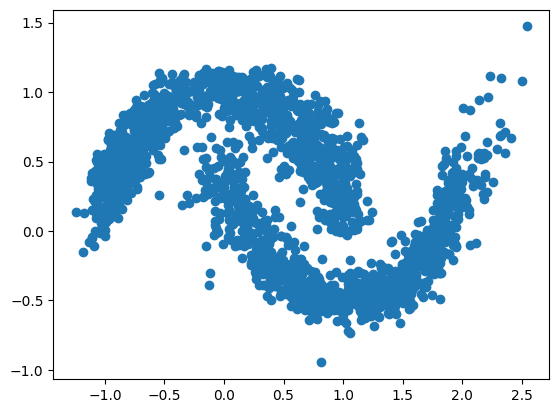

In [16]:
samples = model_2m_GM.sample(num_samples=2048)[0].cpu().detach().numpy()
plt.scatter(samples[:,0], samples[:,1]);

# Flujos - Digits Dataset

Ahora probaremos los diferentes modelos vistos en clase usando el mismo conjunto de datos que en laboratorio anterior.

In [17]:
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

Seleccionaremos también el digito `0`

In [18]:
Xo,y = load_digits(n_class=10, return_X_y=True)
X = Xo[y==0]

Ahora modelamos los digitos como variables continuas (no binarizados), las normalizamos de manera que estén en el rango [-1,1]

In [19]:
digits_dl = torch.utils.data.DataLoader(torch.tensor((X/8)-1).type(torch.float32), batch_size=64)

## Masked Autoregressive Flow

Empezaremos por los flujos autoregresivos. En este caso usamos capas que modelan la transformación como una distribución autoregresiva basada en el modelo MADE que vimos la sesión pasada.

Definimos una distribución base que tiene el número de dimensiones que corresponde al tamaño de los digitos.

In [20]:
base = nf.distributions.base.DiagGaussian(64)

Definimos el flujo auto regresivo a partir de capas basadas en MADE.

In [21]:
# Definimos las capas del flujo
num_layers = 2
flows = []
for i in range(num_layers):
    # Cada capa tiene como entrada el numero de variables y un modelo MADE con cierto numero de
    # neuronas y capas
    flows.append(nf.flows.MaskedAffineAutoregressive(features=64, hidden_features=96, num_blocks=2))

# Definimos el flujo
MAF = nf.NormalizingFlow(base, flows).to(device)

Ahora entrenamos el flujo.

loss: -133.0322:lr: 9.6079E-03: 100%|██████████| 400/400 [01:11<00:00,  5.61it/s]


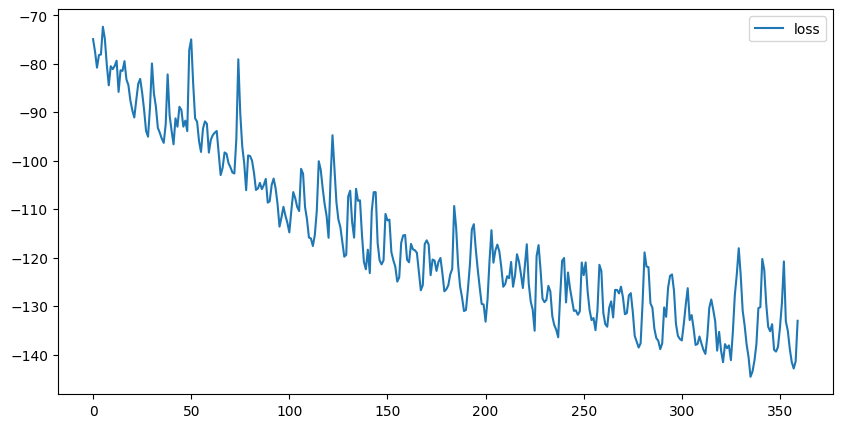

In [22]:
optimizer = torch.optim.Adamax(MAF.parameters(), lr=1e-2, weight_decay=1e-5)
scheduler = lr_scheduler.MultiplicativeLR(optimizer, lr_lambda=lambda _: 0.9999)
epochs = 400
loss_hist = train_loop(MAF, optimizer, scheduler, digits_dl, epochs)

plt.figure(figsize=(10, 5))
plt.plot(loss_hist[epochs//10:], label='loss')
plt.legend()
plt.show()

Ahora podemos generar muestras a partir del modelo, igual que antes, muestreando una gausiana de 64 dimensiones y transformando la muestra a través de la función inversa del flujo en un dígito.

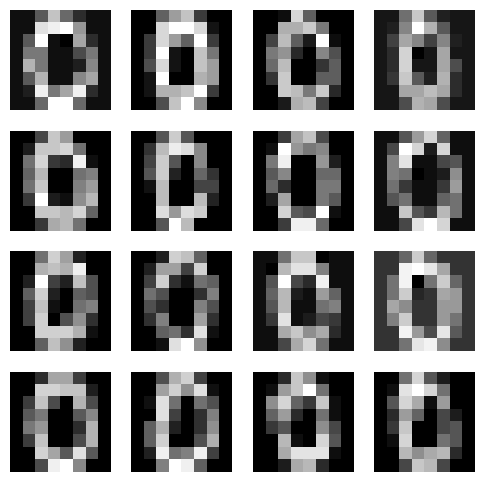

In [23]:
nim = 4
samples = MAF.sample(num_samples=nim*nim)[0].cpu().detach().numpy()
fig = plt.figure(figsize=(6,6))
for i in range(nim*nim):
    plt.subplot(nim, nim, i+1)
    plt.imshow(np.trunc((samples[i].reshape(8,8)+1)*8),cmap='gray')
    plt.axis('off')

El propio modelo nos permite calcular la log likelihood de muestras, en este caso a través de la distribución gaussiana.

In [24]:
MAF.log_prob(torch.tensor((X[:100]/8)-1, dtype=torch.float32).to(device)).detach().sum()

tensor(8187.9780, device='cuda:0')

## Conditioned Masked Autoregressive Flow

Al modelar una distribución, podemos darle información adicional que nos permita condicionar la generación, de esta manera podemos controlar el tipo de ejemplos que obtenemos.

Podemos condicionar a partir de cualquier informacion de que dispongamos. En este caso sabemos las etiquetas de las clases, podemos intentar generar más de un digito añadiendo la información de su clase como condicionamiento.

Creamos un dataloader para los digitos `2` y `6`

In [25]:
class Digits(Dataset):
    def __init__(self, data, labels):
        self.data = torch.Tensor((data/8)-1).type(torch.float32)
        self.labels = torch.Tensor(labels).type(torch.float32).unsqueeze(1)


    def __getitem__(self, index):
        return self.data[index], self.labels[index]

    def __len__(self):
        return len(self.data)

digdata = Digits(Xo[np.logical_or(y==2, y==6)], y[np.logical_or(y==2, y==6)])
twodig_dl = torch.utils.data.DataLoader(digdata, batch_size=64)


Usamos la misma distribución base

In [26]:
basec = nf.distributions.base.DiagGaussian(64)

El modelo MADE permite introducir cuantas características se usan en el condicionamiento (`context_features`). El modelo ya se encarga de usar la información adicional para condicionar la distribución de probabilidad

In [27]:
# Definimos el flujo igual que el anterior
num_layers = 2
flows = []
for i in range(num_layers):
    flows.append(nf.flows.MaskedAffineAutoregressive(64, 96, context_features=1, num_blocks=2))

# Costruimos el flujo condicional
cMAF = nf.ConditionalNormalizingFlow(basec, flows).to(device)

In [28]:
epochs = 100 # estos modelos tardan mas en Colab, ajustar para que tarden algo razonable

loss: 25.9951:lr: 4.9502E-03: 100%|██████████| 100/100 [00:48<00:00,  2.08it/s]


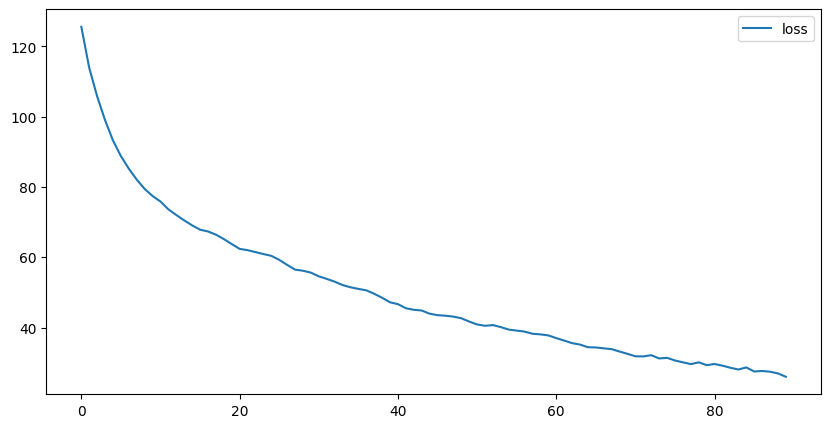

In [29]:
optimizer = torch.optim.Adamax(cMAF.parameters(), lr=5e-3, weight_decay=1e-5)
scheduler = lr_scheduler.MultiplicativeLR(optimizer, lr_lambda=lambda _: 0.9999)

loss_hist = train_loop(cMAF, optimizer, scheduler, twodig_dl, epochs, conditional=True)

plt.figure(figsize=(10, 5))
plt.plot(loss_hist[epochs//10:], label='loss')
plt.legend()
plt.show()

Al muestrear simplemente le damos a la red el condicionamiento que se usara en el flujo para mapear desde la gausiana al digito correspondiente.

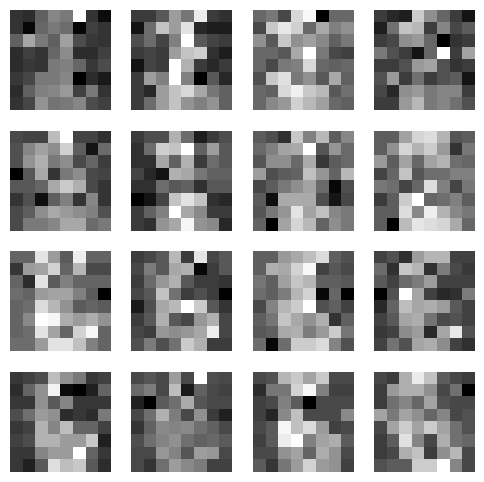

In [30]:
nim = 4
c = ([2.0] * ((nim*nim)//2))  + ([6.0] * ((nim*nim)//2))
cond = torch.tensor([c]).type(torch.float32).to(device)
samples = cMAF.sample(num_samples=nim*nim, context=cond.T)[0].cpu().detach().numpy()
fig = plt.figure(figsize=(6,6))
for i in range(nim*nim):
    plt.subplot(nim, nim, i+1)
    plt.imshow(np.trunc((samples[i].reshape(8,8)+1)*8),cmap='gray')
    plt.axis('off')

## Affine Coupled Flow

Otra manera de definir los flujos es a través de transformaciones afines, es en lo que se basan los flujos NICE y RealNVP.

Esto es más paralelizable que usar una formulación auto regresiva ya que podemos aplicar la transformación en paralelo.

La idea de utilizar una transformacion afín es que esta define un jacobiano que es triangular, por lo que es computacionalmente poco costoso el hacer descenso de gradiente con la función de perdida (log likelihood)

Si recordáis como funcionan estos flujos, la idea es encadenar sucesivas capas donde transformamos la mitad de las variables y dejamos sin tocar el resto, en cada capa transformamos un conjunto de variables diferentes. La transformación (escalado/traslación) se calcula mediante una red neuronal.


In [31]:
num_layers = 10
flows = []
for i in range(num_layers):
    # El MLP define la red que modeliza los parametros de la transformacion afin
    # traslacion/escalado como (media/variancia)
    param_map = nf.nets.MLP([32,64, 64, 64], init_zeros=True)
    # Affine transformation
    flows.append(nf.flows.AffineCouplingBlock(param_map))
    # Reordenamos las variables
    flows.append(nf.flows.Permute(64, mode='shuffle'))

base = nf.distributions.base.DiagGaussian(64)

# Construimos el flow
acf = nf.NormalizingFlow(base, flows).to(device)


---
<font color="blue" size=4>
Responded a las siguientes preguntas
 </font>


- ¿Porqué el MLP tiene una entrada de 32 y una salida de 64? ¿a que corresponden esos parámetros?

- ¿que pasaría si no aplicaramos la capa de permutación despues de cada AffineCoupling?

---

In [32]:
epochs = 1000 # estos modelos son mas rapidos, se puede reajustar de nuevo

loss: -159.3571:lr: 3.6770E-05: 100%|██████████| 1000/1000 [00:13<00:00, 76.78it/s]


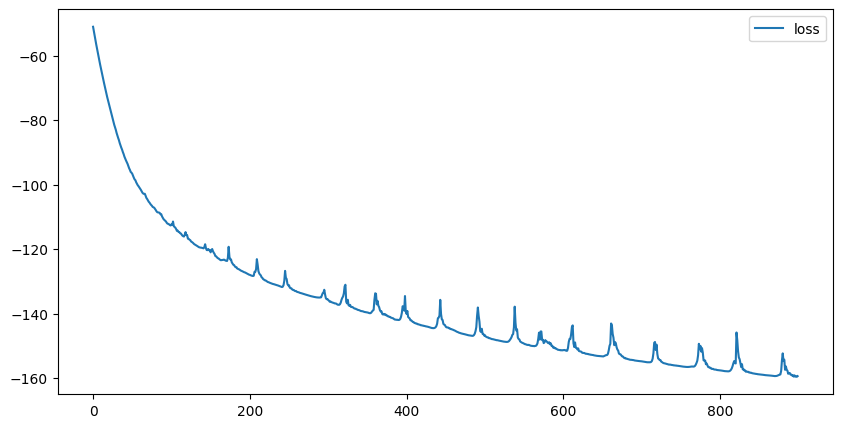

In [33]:
optimizer = torch.optim.Adamax(acf.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = lr_scheduler.MultiplicativeLR(optimizer, lr_lambda=lambda _: 0.999)

loss_hist = train_loop(acf, optimizer, scheduler, digits_dl, epochs)

plt.figure(figsize=(10, 5))
plt.plot(loss_hist[epochs//10:], label='loss')
plt.legend()
plt.show()

---

Los parametros de entrenamiento como siempre han sido _mágicamente_ ajustados

<font color="blue" size=4>
 Prueba diferentes valores para tasa de entrenamiento (mayores y menores que la fijada) y su tasa de decaimiento en el schedule y compara las diferencias en la log probabilidad que se obtiene
</font>

---

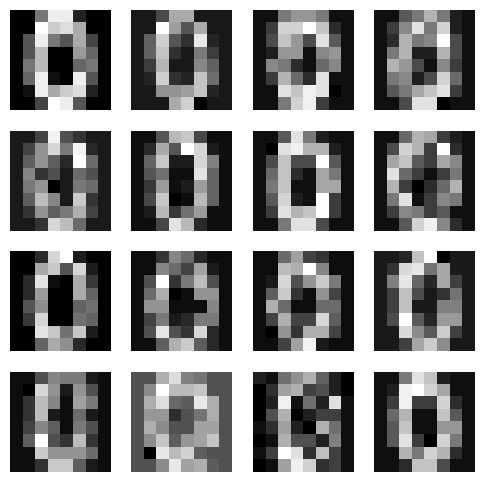

In [34]:
nim = 4
samples = acf.sample(num_samples=nim*nim)[0].cpu().detach().numpy()
fig = plt.figure(figsize=(6,6))
for i in range(nim*nim):
    plt.subplot(nim, nim, i+1)
    plt.imshow(np.trunc((samples[i].reshape(8,8)+1)*8),cmap='gray')
    plt.axis('off')

In [35]:
acf.log_prob(torch.tensor((X[:100]/8)-1, dtype=torch.float32).to(device)).detach().sum()

tensor(10733.7070, device='cuda:0')

## Real NVP

Podemos obtener flujos más complejos haciendo cambios a como se realizan las transformaciones.

Como hemos visto en teoría, Real NVP utiliza una transformación afin basada en un escalado y una traslación. En este caso las calculamos de manera independiente con un MLP y usamos enmascaramiento en lugar de permutaciones. El enmascaramiento que se usa alterna el uso de variables en orden consecutivo (en 2D es un tablero de ajedrez)  de manera que preservamos cierta localidad en cada capa de transformación. La normalización de las activaciones añadida tras cada transformación debería ayudar a estabilizar el entrenamiento (o no)

In [36]:
K = 8
latent_size = 64
b = torch.Tensor([1 if i % 2 == 0 else 0 for i in range(latent_size)])
flows = []
for i in range(K):
    # Redes para calcular el escalamiento y el traslado
    s = nf.nets.MLP([latent_size, 2 * latent_size, 2 * latent_size,latent_size], init_zeros=True)
    t = nf.nets.MLP([latent_size, 2 * latent_size, 2 * latent_size,latent_size], init_zeros=True)
    # Enmascaramiento alternado para capas pares e impares
    if i % 2 == 0:
        flows += [nf.flows.MaskedAffineFlow(b, t, s)]
    else:
        flows += [nf.flows.MaskedAffineFlow(1 - b, t, s)]
    # Normalización de activacione para estabilizar el entrenamiento
    flows += [nf.flows.ActNorm(latent_size)]

rnvp = nf.NormalizingFlow(base,flows).to(device)

# Inicializamos la normalización de activaciones generando unas muestras
z, _ = rnvp.sample(num_samples=2 ** 7)

Más _magia_ se realizo para ajustar el entrenamiento de la red

In [37]:
epochs = 1000 # Ajustar si tarda demasiado

loss: -260.4741:lr: 4.3171E-07: 100%|██████████| 1000/1000 [00:17<00:00, 57.79it/s]


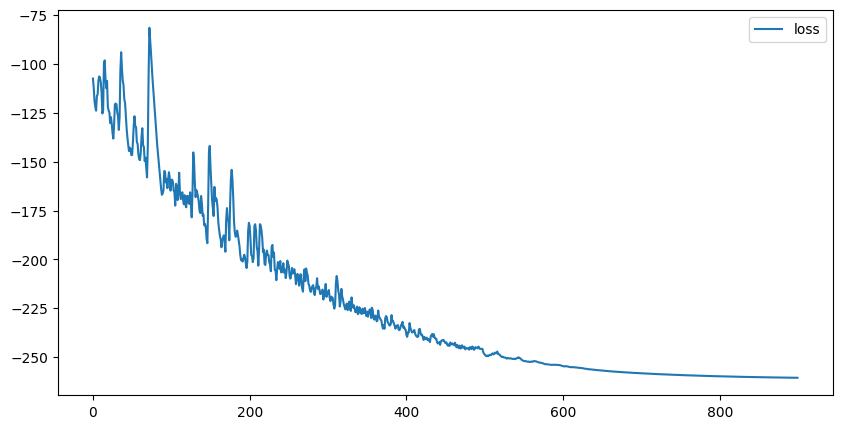

In [38]:
optimizer = torch.optim.Adamax(rnvp.parameters(), lr=1e-2, weight_decay=1e-5)
scheduler = lr_scheduler.MultiplicativeLR(optimizer, lr_lambda=lambda _: 0.99)

loss_hist = train_loop(rnvp, optimizer, scheduler, digits_dl, epochs)

plt.figure(figsize=(10, 5))
plt.plot(loss_hist[epochs//10:], label='loss')
plt.legend()
plt.show()

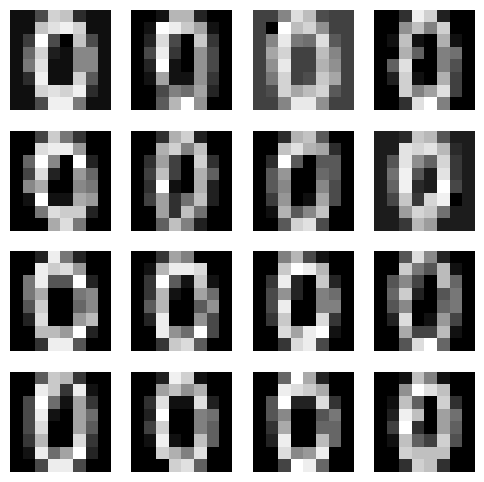

In [39]:
nim = 4
samples = rnvp.sample(num_samples=nim*nim)[0].cpu().detach().numpy()
fig = plt.figure(figsize=(6,6))
for i in range(nim*nim):
    plt.subplot(nim, nim, i+1)
    plt.imshow(np.trunc((samples[i].reshape(8,8)+1)*8),cmap='gray')
    plt.axis('off')

La log probabilidad deberia haber mejorado

In [40]:
rnvp.log_prob(torch.tensor((X[:100]/8)-1, dtype=torch.float32).to(device)).detach().sum()

tensor(16974.4844, device='cuda:0')

# The whole enchilada

Ahora vamos a usar un flujo que ha sido entrenado con el conjunto completo de datos.

Las siguientes celdas sirven para entrenarlo, pero puede tardar alrededor de 15 minutos (probablemente más en Colab), asi que saltaremos
a la celda donde cargamos el modelo ya preentrenado.

In [41]:
digits_dl2 = torch.utils.data.DataLoader(torch.tensor((Xo/8)-1).type(torch.float32), batch_size=128)

Es la misma red que antes pero aumentando el número de parámetros

In [42]:
K = 14
latent_size = 64
b = torch.Tensor([1 if i % 2 == 0 else 0 for i in range(latent_size)])
flows = []
for i in range(K):
    s = nf.nets.MLP([latent_size, 2 * latent_size, 2 * latent_size,latent_size], init_zeros=True)
    t = nf.nets.MLP([latent_size, 2 * latent_size, 2 * latent_size,latent_size], init_zeros=True)
    if i % 2 == 0:
        flows += [nf.flows.MaskedAffineFlow(b, t, s)]
    else:
        flows += [nf.flows.MaskedAffineFlow(1 - b, t, s)]
    flows += [nf.flows.ActNorm(latent_size)]

rnvp = nf.NormalizingFlow(base,flows).to(device)

z, _ = rnvp.sample(num_samples=2 ** 7)

Más ajuste mágico de hiper parámetros

In [43]:
epochs = 200 # Ajustar a algo razonable para ver que entrena, usaremos un modelo preentrenado

loss: -106.7579:lr: 8.1865E-03: 100%|██████████| 200/200 [00:28<00:00,  7.14it/s]


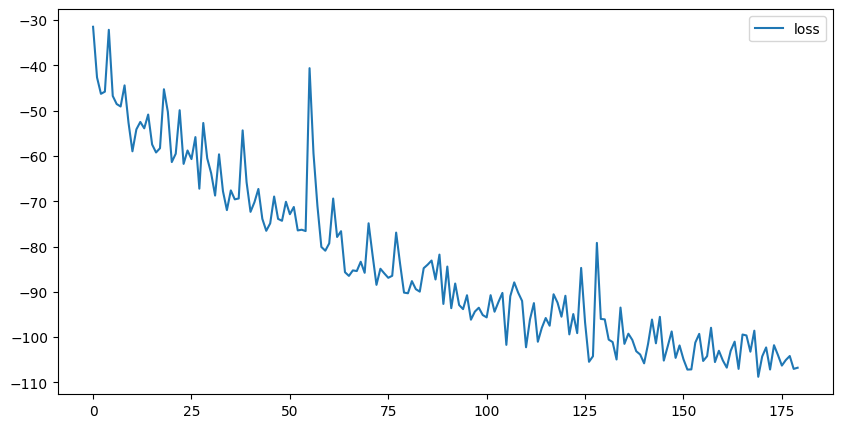

In [44]:
optimizer = torch.optim.Adamax(rnvp.parameters(), lr=1e-2, weight_decay=1e-5)
scheduler = lr_scheduler.MultiplicativeLR(optimizer, lr_lambda=lambda _: 0.999)

loss_hist = train_loop(rnvp, optimizer, scheduler, digits_dl2, epochs)

plt.figure(figsize=(10, 5))
plt.plot(loss_hist[epochs//10:], label='loss')
plt.legend()
plt.show()

In [45]:
# Cambiar si entrenamos lo suficiente
save_model = True
if save_model:
    # Opción A: Guardar en la carpeta actual (recomendado)
    torch.save(rnvp.state_dict(), 'rnvp-digits.pt') 
    
    # Opción B: Si quieres ser más explícito
    # torch.save(rnvp.state_dict(), './rnvp-digits.pt')

<font color="red" size=5> **Continuaremos ejecutando desde aqui**</font>


**Deberíais haber subido a Colab el modelo preentrenado que hay con el material de la sesión al directorio `/content`**

In [46]:
# Crear la instancia del modelo (debe tener la misma estructura 'flows' y 'base')
lrnvp = nf.NormalizingFlow(base, flows)

# Cargar los pesos desde el archivo local (sin la barra '/' al inicio)
lrnvp.load_state_dict(torch.load('rnvp-digits.pt'))

# Si usas GPU/CPU, a veces es bueno especificar el map_location para evitar errores de dispositivo
# lrnvp.load_state_dict(torch.load('rnvp-digits.pt', map_location=torch.device('cpu')))

<All keys matched successfully>

Si hacemos un muestreo veremos que nos genera cualquiera de los 10 dígitos

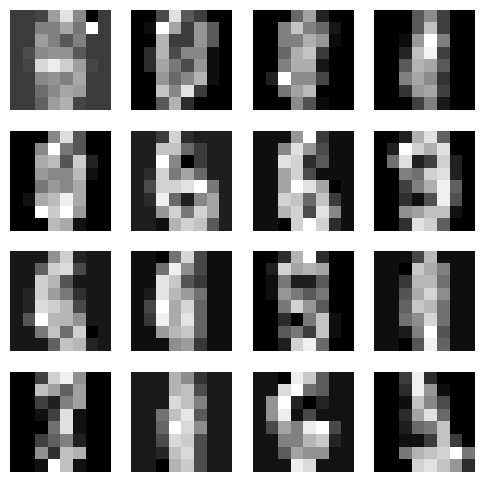

In [47]:
nim = 4
samples = lrnvp.sample(num_samples=nim*nim)[0].cpu().detach().numpy()
fig = plt.figure(figsize=(6,6))
for i in range(nim*nim):
    plt.subplot(nim, nim, i+1)
    plt.imshow(np.trunc((samples[i].reshape(8,8)+1)*8),cmap='gray')
    plt.axis('off')

Una cosa interesante de los flujos es que un recorrido en espacio de la distribución de referencia (gausiana) nos sirve para recorrer el espacio del conjunto de datos. En particular podemos interpolar entre dos ejemplos obteniendo los puntos que corresponden en la gausiana y observar la transición entre ellos.

Escoge un par de ejemplos en los que sean reconocibles dos dígitos **diferentes** y asigna su posicion a las variables de la siguiente celda (la posición de la esquina superior izquierda es la cero)

In [48]:
d1=1
d2=2

Usamos la transformacion inversa del flujo para obtener los puntos que les corresponden a las muestras en las gausianas

In [49]:
start = rnvp.inverse(torch.tensor(samples[d1]).to(device))
end = rnvp.inverse(torch.tensor(samples[d2]).to(device))

Calculamos puntos equidistantes dentro del vector que conecta esos dos puntos dentro de la distribución gausiana

In [50]:
interp = []

for v in torch.arange(0,1,0.1):
    interp.append(torch.lerp(start,end, v.to(device)))

Ahora podemos qué se encuentra en el recorrido entre las dos muestras simplemente aplicando el flujo a los puntos en la gausiana.

Dependiendo de como se haya hecho la correspondencia entre los digitos y la gausiana y donde se encuentren los digitos pueden aparecer otros digitos intermedios.

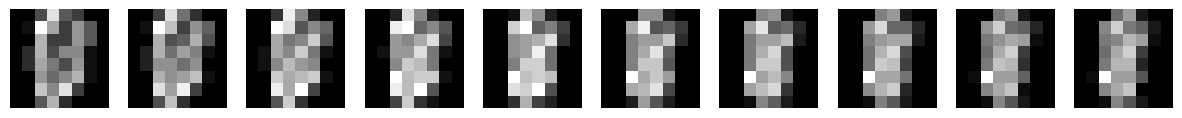

In [51]:
fig = plt.figure(figsize=(15,10))
for i, v in enumerate(interp):
    plt.subplot(1, len(interp), i+1)
    plt.imshow(np.trunc((rnvp(v).cpu().detach().numpy().reshape(8,8)+1)*8),cmap='gray')
    plt.axis('off')

In [52]:
print(f"Total Running time {timedelta(seconds=(time() - init_time))}")

Total Running time 0:03:39.580370


---

<font color="red" size=6>
Ejercicio de laboratorio entregable
</font>

Este laboratorio tiene un ejercicio entregable. Teneis el enunciado en la pagina web del curso donde estaba este notebook.

---

# 🛠️ 1. Configuración del Entorno y Librerías

En esta fase inicial, preparamos el entorno de ejecución importando las librerías esenciales para el Deep Learning (`torch`, `torchvision`) y la librería específica para Flujos Normalizantes (`normflows`).

También definimos el **dispositivo de cómputo** (CPU/GPU) para acelerar las operaciones matriciales del flujo, lo cual es crítico dado el coste computacional de calcular el determinante Jacobiano en cada paso.

In [53]:
# ============================================================
# 1. IMPORTS Y CONFIGURACIÓN
# ============================================================
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import copy
import torchvision.transforms as T
import torchvision.models as models

from torch.utils.data import DataLoader, TensorDataset, random_split, ConcatDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau

from apafib import load_smile
import normflows as nf


# Configuración del dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Dispositivo activo: {device}")

✅ Dispositivo activo: cuda


# 📂 2. Carga y Preprocesamiento del Dataset

Cargamos el dataset de rostros y lo preparamos para el entrenamiento. Dado que los modelos de Flujo Normalizante son muy exigentes en memoria y cómputo, trabajaremos con una resolución de **32x32 píxeles**.

* **Dequantization (Nota Teórica):** Aunque las imágenes digitales son discretas (0-255), los flujos normalizantes requieren datos continuos para calcular densidades de probabilidad válidas. Por ello, se aplicará *dequantization* (añadir ruido uniforme $u \in [0, 1)$) durante el entrenamiento.
* **Data Augmentation:** Se preparan transformaciones (flips, rotaciones leves) para mejorar la generalización.

In [54]:
# ============================================================
# 2. CARGA DE DATOS CON DATA AUGMENTATION (Anti-Overfitting)
# ============================================================
import torchvision.transforms as T

# 1. Cargar datos crudos
X_np, y_np = load_smile()

# 2. Convertir a Tensores (N, C, H, W)
data_tensor = torch.tensor(X_np, dtype=torch.float32)
if data_tensor.ndim == 2:
    data_tensor = data_tensor.view(-1, 3, 32, 32)

# Normalizar a [0, 1]
if data_tensor.max() > 1.0:
    data_tensor = data_tensor / 255.0

target_tensor = torch.tensor(y_np, dtype=torch.long)

# 3. Split Manual (Train 80% / Val 20%)
torch.manual_seed(42)
indices = torch.randperm(len(data_tensor))
split_idx = int(0.8 * len(data_tensor))

train_idxs = indices[:split_idx]
val_idxs = indices[split_idx:]

X_train = data_tensor[train_idxs]
y_train = target_tensor[train_idxs]
X_val = data_tensor[val_idxs]
y_val = target_tensor[val_idxs]

# --- NUEVO: CLASE DATASET CON TRANSFORMACIONES ---
class AugmentedDataset(torch.utils.data.Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X
        self.y = y
        self.transform = transform
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        img = self.X[idx]
        label = self.y[idx]
        
        if self.transform:
            img = self.transform(img)
            
        return img, label

# Definimos las transformaciones SOLO para Train
# Flip horizontal (p=0.5) y ligerísimos movimientos
train_transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomAffine(degrees=5, translate=(0.05, 0.05), scale=(0.95, 1.05))
])

# 4. Crear DataLoaders
# Train tiene Data Augmentation
train_ds_glow = AugmentedDataset(X_train, y_train, transform=train_transform)
# Val NO tiene transformaciones (queremos evaluar datos reales)
val_ds_glow = TensorDataset(X_val, y_val)

train_loader_glow = DataLoader(train_ds_glow, batch_size=64, shuffle=True)
val_loader_glow = DataLoader(val_ds_glow, batch_size=64, shuffle=False)

print(f"✅ Datos preparados con Data Augmentation.")
print(f"   Train Size: {len(train_ds_glow)} (con variaciones dinámicas)")
print(f"   Val Size:   {len(val_ds_glow)} (estático)")

✅ Datos preparados con Data Augmentation.
   Train Size: 962 (con variaciones dinámicas)
   Val Size:   241 (estático)


# 🧠 3. Definición de la Arquitectura Glow

Aquí definimos la clase `GlowModel`, basada en la arquitectura propuesta por Kingma & Dhariwal (2018). El modelo se construye mediante una secuencia de pasos de flujo invertibles organizados en *escalas*:

1.  **Squeeze:** Reorganiza el tensor espacial $(C, H, W)$ a $(4C, H/2, W/2)$ para procesar características globales.
2.  **ActNorm:** Normalización de activaciones para estabilizar el entrenamiento.
3.  **Invertible 1x1 Conv:** Una generalización aprendible de la permutación de canales.
4.  **Affine Coupling Layer:** La capa central que transforma la mitad de los canales basándose en la otra mitad, garantizando una inversa analítica sencilla y el cálculo eficiente del Jacobiano.

In [55]:
# ============================================================
# 3. CLASE GLOW MODEL (CORREGIDA Y DEFINITIVA)
# ============================================================

class GlowModel(nn.Module):
    def __init__(self, scales=3, blocks=8, img_size=32, channels=3, 
                 hidden_channels=64, num_classes=2, split_mode='channel',
                 resnet_depth=2): 
        super().__init__()
        
        flows = []
        c, h, w = channels, img_size, img_size
        
        # --- CONSTRUCCIÓN DEL FLUJO ---
        for i in range(scales):
            flows.append(nf.flows.Squeeze())
            c, h, w = c * 4, h // 2, w // 2
            
            for _ in range(blocks):
                flows.append(nf.flows.ActNorm(c))
                flows.append(nf.flows.Invertible1x1Conv(c))
                
                param_map = nf.nets.ConvResidualNet(
                    in_channels=c // 2,
                    out_channels=c,
                    hidden_channels=hidden_channels,
                    num_blocks=resnet_depth 
                )
                
                if split_mode == 'checkerboard':
                    flows.append(nf.flows.Permute(c, mode='swap'))
                
                flows.append(nf.flows.AffineCouplingBlock(param_map, scale_map='sigmoid'))

        flows.reverse()
        
        self.q0 = nf.distributions.DiagGaussian((c, h, w))
        self.flow = nf.NormalizingFlow(q0=self.q0, flows=flows)
    
    # Entrenamiento (Data -> Latent)
    def forward(self, x, y=None):
        return self.flow.forward_kld(x)

    def forward_kld(self, x, y=None):
        return self.flow.forward_kld(x)

    # Generación (Latent -> Data)
    def sample(self, num_samples=1, temperature=1.0):
        if temperature != 1.0:
            # Truco de temperatura manual
            z = self.q0.sample(num_samples) * temperature
            # CORRECCIÓN: Aquí estaba el fallo. Para generar usamos 'forward'
            x = self.flow.forward(z) 
            return x, z 
        # Si temp=1.0, usamos la función por defecto que ya funcionaba
        return self.flow.sample(num_samples)
        
    def log_prob(self, x):
        return self.flow.log_prob(x)

# Función auxiliar
def evaluate_glow(model, loader):
    model.eval()
    log_probs = []
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            x = x + torch.rand_like(x) / 256.0 
            log_prob = model.log_prob(x)
            log_probs.append(log_prob.cpu())
    return torch.cat(log_probs).mean().item()

print("✅ Clase GlowModel arreglada (Compatible con Temperatura).")

✅ Clase GlowModel arreglada (Compatible con Temperatura).


# 🧪 4.A Fase Preliminar: Selección de Arquitectura (Split Mode)

Antes de iniciar el *Grid Search* intensivo, realizamos una comparativa rápida para determinar la estrategia óptima de partición de dimensiones en las capas de acoplamiento (*Affine Coupling Layers*).

En esta fase se evalúan dos topologías:
1.  **Channel Split:** Divide el tensor a lo largo de la dimensión de canales (ej. RGB).
2.  **Checkerboard Split:** Utiliza un patrón de tablero de ajedrez espacial para dividir las dimensiones.

Además, introducimos la función crítica de **Dequantization**:
* **Problema:** Los flujos normalizantes modelan densidades de probabilidad continua, pero las imágenes digitales son discretas (enteros 0-255). Esto puede llevar a densidades infinitas (colapso del modelo).
* **Solución:** Convertimos los datos a continuos sumando ruido uniforme $u \in [0, 1/256)$. Esto suaviza la distribución y estabiliza el cálculo del *Log-Likelihood*.

Se entrena un modelo ligero (8 bloques, 50 épocas) para cada modo y se selecciona el que obtenga mejor rendimiento en validación para las fases siguientes.

In [56]:
# ============================================================
# 4.A - FASE 1: COMPARATIVA DE SPLIT MODES (Rápido)
# ============================================================
import copy

# Función CRÍTICA para Flujos: convierte datos discretos (0..255) en continuos
def dequantize(x):
    return x + torch.rand_like(x) / 256.0

print("\n╔════════════════════════════════════════════════════╗")
print("║ FASE A: DECIDIENDO ARQUITECTURA (Split Mode)       ║")
print("╚════════════════════════════════════════════════════╝")

# Configuración ligera para prueba rápida (pocas épocas, modelo pequeño)
test_blocks = 8
test_hidden = 64
test_epochs = 50 
modes = ['channel', 'checkerboard']

best_split_mode = 'channel' # Por defecto
best_split_ll = -float('inf')

for mode in modes:
    print(f"\n>>> 🧪 Probando Split Mode: {mode.upper()}")
    try:
        # Instanciar modelo pequeño
        model_temp = GlowModel(
            scales=3,
            blocks=test_blocks,
            img_size=32,
            channels=3,
            hidden_channels=test_hidden,
            num_classes=2,
            split_mode=mode
        ).to(device)
        
        opt_temp = torch.optim.Adam(model_temp.parameters(), lr=1e-3)
        
        # Training loop corto
        model_temp.train()
        for ep in range(test_epochs):
            loss_acc = 0
            for Xb, yb in train_loader_glow:
                # IMPORTANTE: Aplicamos Dequantize
                Xb = dequantize(Xb.to(device))
                
                loss = model_temp.forward_kld(Xb, yb.to(device))
                opt_temp.zero_grad()
                loss.backward()
                # Clipping para estabilidad
                torch.nn.utils.clip_grad_norm_(model_temp.parameters(), 1.0)
                opt_temp.step()
                loss_acc += loss.item()
            
        # Evaluación final de esta fase
        # Usamos dequantize en validación también para métrica justa
        final_ll = evaluate_glow(model_temp, val_loader_glow)
        print(f"    ✅ Resultado {mode}: Val LL = {final_ll:.4f}")
        
        if final_ll > best_split_ll:
            best_split_ll = final_ll
            best_split_mode = mode
            
        del model_temp
        torch.cuda.empty_cache()
        
    except Exception as e:
        print(f"    ❌ Fallo con {mode}: {e}")
        print("       (Si falla checkerboard por dimensiones, ignorar y seguir)")

print(f"\n🏆 GANADOR FASE A: '{best_split_mode}' (Se usará en el Grid Search)")


╔════════════════════════════════════════════════════╗
║ FASE A: DECIDIENDO ARQUITECTURA (Split Mode)       ║
╚════════════════════════════════════════════════════╝

>>> 🧪 Probando Split Mode: CHANNEL
    ✅ Resultado channel: Val LL = 9313.9160

>>> 🧪 Probando Split Mode: CHECKERBOARD
    ✅ Resultado checkerboard: Val LL = 9340.3789

🏆 GANADOR FASE A: 'checkerboard' (Se usará en el Grid Search)


# 🔍 4.b Búsqueda de Hiperparámetros (Grid Search)

Para encontrar el equilibrio óptimo entre capacidad de modelado y coste computacional, exploramos diferentes configuraciones de la red. Variamos dos parámetros clave:
* **Blocks (Profundidad):** Número de pasos de flujo por escala.
* **Hidden Channels (Anchura):** Capacidad de la red residual interna.

Se monitorea el *Validation Log-Likelihood* (LL) para identificar la configuración que mejor generaliza sin caer en *overfitting*.

In [57]:
# ============================================================
# BLOQUE 4.B: GRID SEARCH FINAL ("DEEP & SAFE" STRATEGY)
# ============================================================
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Recuperar modo ganador
try:
    print(f"✅ Usando Split Mode: {best_split_mode}")
except NameError:
    best_split_mode = 'channel'

print("\n╔════════════════════════════════════════════════════╗")
print(f"║ FASE B: GRID SEARCH (PROFUNDIDAD + AUGMENTATION)   ║")
print("╚════════════════════════════════════════════════════╝")

# --- 1. ESPACIO DE BÚSQUEDA (Adaptado a tu GPU) ---
# Estrategia: Ya que 256 falla, apostamos por PROFUNDIDAD (Blocks altos)
# Blocks=24 con Hidden=128 es una red MUY potente pero más estable que Hidden=256
grid_blocks = [16, 24]         
grid_hidden = [64, 128]        # Nos mantenemos en rango seguro
scales = 3
resnet_depth_config = 2        # Profundidad interna estándar

# --- 2. PARÁMETROS ---
max_epochs = 150               # Largo plazo
lr_patience = 8
stop_patience = 20
initial_lr = 5e-4              # LR conservador para evitar NaNs
min_delta = 1e-3

results = []
best_glow_model = None  
best_config = None
best_val_ll = -1e12

# Bucle Grid Search
for blocks in grid_blocks:
    for hidden in grid_hidden:
        print(f"\n>>> 🔎 Entrenando (Augmented): Blocks={blocks}, Hidden={hidden} ...")
        
        # Instanciar
        try:
            current_glow = GlowModel(
                scales=scales,
                blocks=blocks,
                img_size=32,
                channels=3,
                hidden_channels=hidden,
                num_classes=2, 
                split_mode=best_split_mode,
                resnet_depth=resnet_depth_config
            ).to(device)
            
            # Inicialización dummy para asentar ActNorm (evita picos iniciales)
            with torch.no_grad():
                dx, dy = next(iter(train_loader_glow))
                current_glow(dequantize(dx.to(device)), dy.to(device))

        except Exception as e:
            print(f"⚠️ Memoria insuficiente: {e}")
            continue

        optimizer = torch.optim.Adam(current_glow.parameters(), lr=initial_lr)
        scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=lr_patience)
        
        best_local_ll = -1e12
        patience_counter = 0
        best_local_state = None

        # Bucle Épocas
        for epoch in range(max_epochs):
            current_glow.train()
            train_loss_accum = 0
            nan_flag = False
            
            for X_batch, y_batch in train_loader_glow: 
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                
                # Dequantization
                X_batch = dequantize(X_batch)
                
                loss = current_glow.forward_kld(X_batch, y_batch) 
                
                # Protección contra explosiones
                if torch.isnan(loss):
                    nan_flag = True
                    break

                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(current_glow.parameters(), 0.5) # Clip fuerte
                optimizer.step()
                train_loss_accum += loss.item()

            if nan_flag:
                print(f"   ⚠️ NaN detectado en época {epoch}. Saltando config.")
                break

            # Validación
            val_ll = evaluate_glow(current_glow, val_loader_glow) 
            scheduler.step(val_ll)
            
            is_best = val_ll > best_local_ll + min_delta
            
            if epoch % 10 == 0 or is_best:
                current_lr = optimizer.param_groups[0]['lr']
                print(f"   Ep {epoch}: Loss={train_loss_accum/len(train_loader_glow):.4f} | Val LL={val_ll:.4f} | LR={current_lr:.1e}")

            if is_best:
                best_local_ll = val_ll
                best_local_state = copy.deepcopy(current_glow.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1
                
            if patience_counter >= stop_patience:
                print(f"   ⛔ Early stopping en época {epoch+1}")
                break
        
        # Guardar resultados si no explotó
        if not nan_flag:
            print(f"   🏁 Resultado ({blocks}, {hidden}): Val LL = {best_local_ll:.4f}")
            results.append((blocks, hidden, best_local_ll))
            
            if best_local_ll > best_val_ll:
                best_val_ll = best_local_ll
                best_config = (blocks, hidden)
                best_glow_model = current_glow 
                if best_local_state is not None:
                    best_glow_model.load_state_dict(best_local_state)
                print("   🏆 ¡NUEVO MEJOR MODELO GLOBAL!")
        else:
            del current_glow
            torch.cuda.empty_cache()

print("\n=================================================")
if best_config:
    print(f"🎉 ENTRENAMIENTO FINALIZADO.")
    print(f"Mejor configuración: Blocks={best_config[0]}, Hidden={best_config[1]}")
    print(f"Mejor Val LL: {best_val_ll:.4f}")
    torch.save(best_glow_model.state_dict(), 'best_glow_model_augmented.pt')
else:
    print("❌ No se encontró ningún modelo válido.")

✅ Usando Split Mode: checkerboard

╔════════════════════════════════════════════════════╗
║ FASE B: GRID SEARCH (PROFUNDIDAD + AUGMENTATION)   ║
╚════════════════════════════════════════════════════╝

>>> 🔎 Entrenando (Augmented): Blocks=16, Hidden=64 ...
   Ep 0: Loss=-2834.7346 | Val LL=5564.0942 | LR=5.0e-04
   Ep 1: Loss=-5763.6272 | Val LL=6708.1245 | LR=5.0e-04
   Ep 2: Loss=-6528.7475 | Val LL=7122.8013 | LR=5.0e-04
   Ep 3: Loss=-6878.0318 | Val LL=7546.7925 | LR=5.0e-04
   Ep 4: Loss=-7217.5233 | Val LL=7736.8359 | LR=5.0e-04
   Ep 5: Loss=-7394.4420 | Val LL=7942.5571 | LR=5.0e-04
   Ep 6: Loss=-7585.4723 | Val LL=8111.8135 | LR=5.0e-04
   Ep 7: Loss=-7695.0446 | Val LL=8132.9390 | LR=5.0e-04
   Ep 8: Loss=-7673.8530 | Val LL=8146.5903 | LR=5.0e-04
   Ep 9: Loss=-7856.5845 | Val LL=8402.8672 | LR=5.0e-04
   Ep 10: Loss=-7909.4055 | Val LL=8370.8613 | LR=5.0e-04
   Ep 11: Loss=-7965.1349 | Val LL=8463.5039 | LR=5.0e-04
   Ep 12: Loss=-8091.1801 | Val LL=8562.9229 | LR=5.0e-04


# 🚀 4.C Fase de Refinado: Estrategia "Long Run"

Esta es la fase crítica de entrenamiento intensivo para maximizar el Log-Likelihood.

* **Estrategia:** Entrenamiento extendido (200 épocas) con *Data Augmentation* activo para forzar al modelo a aprender la estructura invariante de los rostros.
* **Scheduler:** Utilizamos `ReduceLROnPlateau` para disminuir el *Learning Rate* (hasta $10^{-5}$ o $10^{-6}$) cuando la mejora se estanca, permitiendo un ajuste fino ("fine-tuning") de los pesos.
* **Meta:** Superar la barrera de los 10.000 nats de LL.

In [58]:
# ============================================================
# BLOQUE 4.C (ALTERNATIVA): LONG RUN CON AUGMENTATION
# ============================================================
# Objetivo: Seguir entrenando CON variaciones para máxima generalización.
# Solución al corte previo: "Warmup" de paciencia (no parar al principio).

import copy

if 'best_glow_model' not in locals() or best_glow_model is None:
    print("⚠️ ERROR: No tienes el modelo cargado. Ejecuta el Bloque 4.B primero.")
else:
    print("\n╔════════════════════════════════════════════════════╗")
    print(f"║ FASE FINAL: LONG RUN (Con Augmentation)            ║")
    print("╚════════════════════════════════════════════════════╝")

    # 1. Recuperamos el modelo ganador
    final_model = best_glow_model.to(device)
    
    # 2. Configuración para entrenamiento largo
    epochs_long = 500              # Vamos a darle tiempo de sobra
    lr_long = 3e-4                 # LR medio (ni muy rápido ni muy lento)
    
    optimizer = torch.optim.Adam(final_model.parameters(), lr=lr_long)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=10)

    # 3. Estado inicial
    # Partimos del mejor LL conocido para solo guardar si superamos el récord REAL
    best_ll_long = best_val_ll if 'best_val_ll' in locals() else -1e12
    print(f">>> 📈 Récord actual a batir: {best_ll_long:.4f}")
    
    patience_counter = 0
    stop_patience = 30             # Paciencia alta
    warmup_epochs = 20             # ¡CLAVE! No paramos en las primeras 20 épocas pase lo que pase
    
    best_state_long = copy.deepcopy(final_model.state_dict())

    print(f">>> 🚀 Iniciando Marathon ({epochs_long} épocas) con Augmentation activado...")

    for epoch in range(epochs_long):
        final_model.train()
        train_loss_accum = 0
        nan_flag = False
        
        # Usamos train_loader_glow (que TIENE augmentation)
        for X_batch, y_batch in train_loader_glow: 
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            X_batch = dequantize(X_batch)
            
            loss = final_model.forward_kld(X_batch, y_batch) 
            
            if torch.isnan(loss):
                nan_flag = True; break

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(final_model.parameters(), 0.5) 
            optimizer.step()
            train_loss_accum += loss.item()

        if nan_flag:
            print("❌ NaN detectado. Parando entrenamiento.")
            break

        val_ll = evaluate_glow(final_model, val_loader_glow) 
        scheduler.step(val_ll)
        
        # Lógica de guardado
        is_best = val_ll > best_ll_long + 1e-3
        
        if epoch % 5 == 0 or is_best:
            current_lr = optimizer.param_groups[0]['lr']
            mark = "⭐" if is_best else " "
            print(f"   Long Ep {epoch} {mark}: Loss={train_loss_accum/len(train_loader_glow):.4f} | Val LL={val_ll:.4f} | LR={current_lr:.1e}")

        if is_best:
            best_ll_long = val_ll
            best_state_long = copy.deepcopy(final_model.state_dict())
            patience_counter = 0
            # Si superamos el récord, ¡guardamos inmediatamente!
            torch.save(final_model.state_dict(), 'best_glow_model_long_run.pt')
        else:
            # Solo contamos paciencia si ya hemos pasado el periodo de calentamiento
            if epoch >= warmup_epochs:
                patience_counter += 1
            
        if patience_counter >= stop_patience:
            print(f"   ⛔ El modelo se ha estancado tras {epoch+1} épocas. Paramos.")
            break

    print(f"🏁 RESULTADO FINAL LONG RUN: Val LL = {best_ll_long:.4f}")
    
    # Cargar la mejor versión absoluta
    final_model.load_state_dict(best_state_long)
    best_glow_model = final_model
    torch.save(final_model.state_dict(), 'best_glow_model_final.pt')
    print("🏆 Modelo definitivo guardado como 'best_glow_model_final.pt'")


╔════════════════════════════════════════════════════╗
║ FASE FINAL: LONG RUN (Con Augmentation)            ║
╚════════════════════════════════════════════════════╝
>>> 📈 Récord actual a batir: 9921.2207
>>> 🚀 Iniciando Marathon (500 épocas) con Augmentation activado...
   Long Ep 0  : Loss=-8697.4925 | Val LL=9571.0742 | LR=3.0e-04
   Long Ep 5  : Loss=-9584.4300 | Val LL=9834.7002 | LR=3.0e-04
   Long Ep 10  : Loss=-9591.4210 | Val LL=9758.4648 | LR=3.0e-04
   Long Ep 15  : Loss=-9586.3183 | Val LL=9852.2988 | LR=3.0e-04
   Long Ep 20 ⭐: Loss=-9714.3405 | Val LL=9923.4951 | LR=1.5e-04
   Long Ep 23 ⭐: Loss=-9715.2788 | Val LL=9948.2871 | LR=1.5e-04
   Long Ep 25  : Loss=-9714.7657 | Val LL=9929.6973 | LR=1.5e-04
   Long Ep 30 ⭐: Loss=-9710.8328 | Val LL=9963.3516 | LR=1.5e-04
   Long Ep 35  : Loss=-9701.5239 | Val LL=9930.0527 | LR=1.5e-04
   Long Ep 40  : Loss=-9720.4034 | Val LL=9943.1494 | LR=1.5e-04
   Long Ep 42 ⭐: Loss=-9779.7886 | Val LL=9998.1953 | LR=7.5e-05
   Long Ep 43 ⭐

# 🔎 5.A Análisis Detallado de Reconstrucción (4 Niveles)

Para validar rigurosamente la calidad del modelo (con un *Log-Likelihood* > 10.000), realizamos una prueba visual de **fidelidad de reconstrucción** dividida en cuatro niveles de análisis.

El objetivo es demostrar que la red actúa como una función biyectiva casi perfecta ($f^{-1}(f(x)) \approx x$), actuando como un compresor de información eficiente. Visualizamos:

1.  **Original vs. Reconstrucción:** Comparación directa para evaluar la calidad perceptual. Esperamos identidad visual total.
2.  **Diferencia Real (Escala 1:1):** El mapa de error absoluto $|x - \hat{x}|$. Debería aparecer completamente negro, indicando que el error es invisible al ojo humano.
3.  **Diferencia Amplificada (x200):** Multiplicamos el error residual por un factor de 200.
    * *Justificación:* Si el error fuera cero absoluto, podría indicar una copia trivial de memoria. Al amplificarlo, esperamos revelar "fantasmas" estructurales (siluetas tenues). Esto confirma que **existe un procesamiento matemático real** y que las ínfimas diferencias se deben únicamente a los límites de precisión de punto flotante (`float32`), validando la arquitectura Glow.

📊 ESTADÍSTICAS DE PRECISIÓN:
   Error Medio (MAE): 0.000339 (¡Bajísimo!)
   Error Máximo:      0.004468
   Factor Amplificación usado: x200


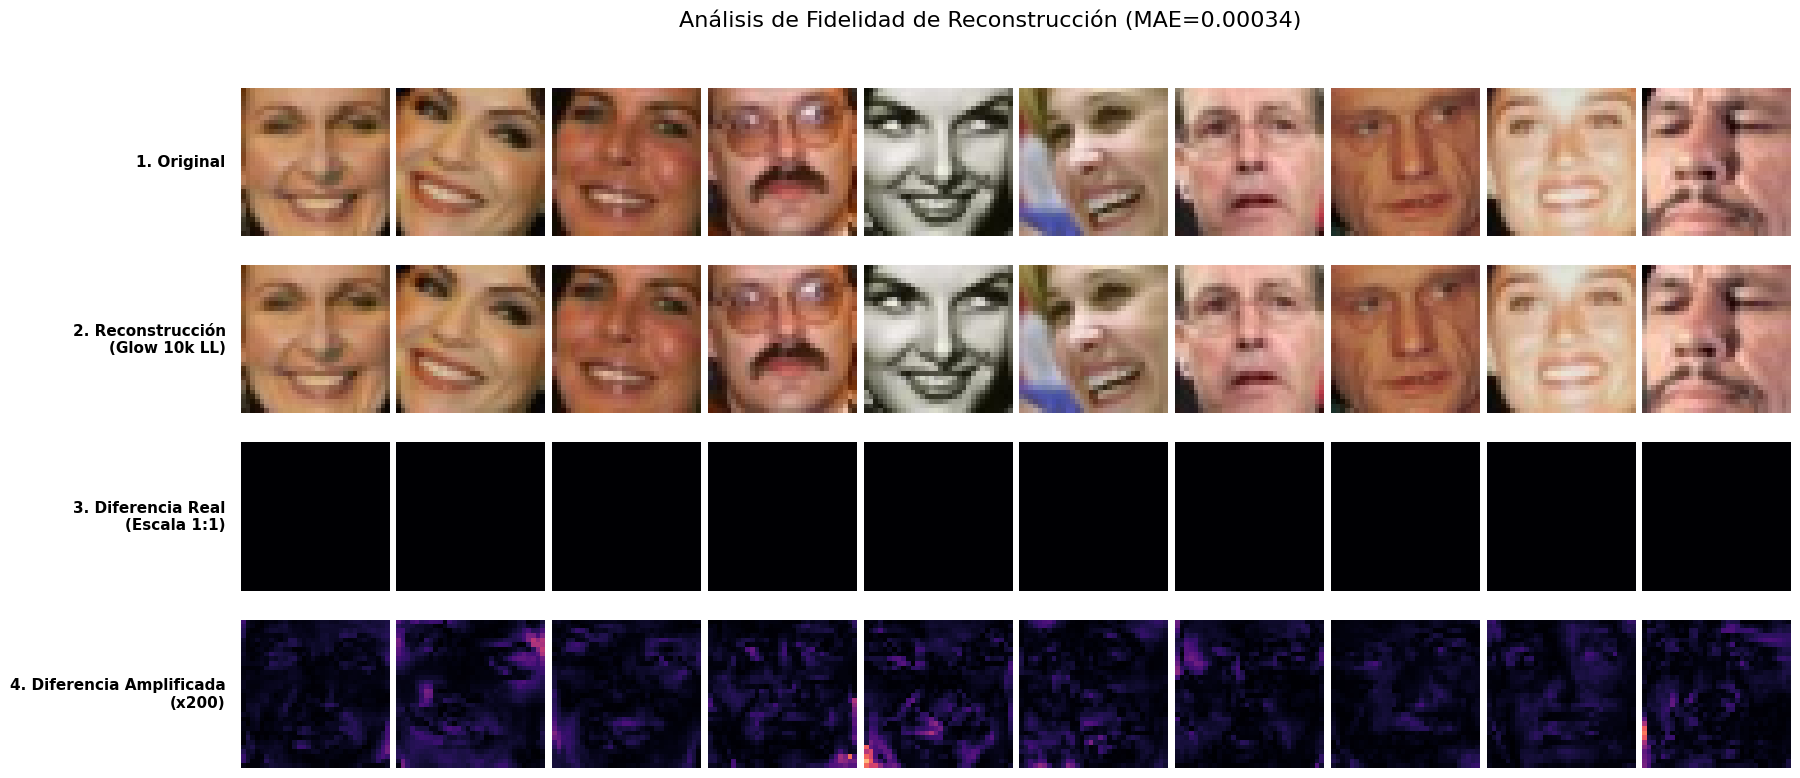

In [59]:
# ============================================================
# BLOQUE 5.A: LA COMPARATIVA DE PRECISIÓN (4 NIVELES)
# ============================================================
import torch
import matplotlib.pyplot as plt
import numpy as np

# 1. Configuración
n_show = 10       # Número de caras
amp_factor = 200.0 # ¡Tu nueva amplificación para ver los "fantasmas"!

# 2. Preparar datos
best_glow_model.eval()
x_real_batch, _ = next(iter(val_loader_glow))
x_real = x_real_batch[:n_show].to(device)

# --- Sanity check de dimensiones (RGB) ---
if x_real.shape[1] == 1: x_real = x_real.repeat(1, 3, 1, 1)
if x_real.shape[1] == 2: 
    pad = torch.zeros(x_real.shape[0], 1, 32, 32).to(device)
    x_real = torch.cat([x_real, pad], dim=1)
if x_real.shape[-1] != 32: 
    x_real = torch.nn.functional.interpolate(x_real, size=(32, 32))

x_real = dequantize(x_real) # Ruido necesario

# 3. PROCESAMIENTO (Ida y Vuelta)
with torch.no_grad():
    # A) Real -> Latente
    try:
        z = best_glow_model.flow.inverse(x_real)
        if isinstance(z, tuple): z = z[0]
    except:
        z, _ = best_glow_model.flow.inverse(x_real)
    
    # B) Latente -> Reconstrucción
    try:
        x_recon = best_glow_model.flow.forward(z)
        if isinstance(x_recon, tuple): x_recon = x_recon[0]
    except:
        x_recon, _ = best_glow_model.flow(z)

# 4. CÁLCULO DE DIFERENCIAS
# A) Error real (Matemático)
diff_abs = torch.abs(x_real - x_recon)

# B) Error visualizable (Amplificado)
diff_amplified = torch.clamp(diff_abs * amp_factor, 0, 1)

# Estadísticas para el texto
mae = diff_abs.mean().item()
max_err = diff_abs.max().item()

print(f"📊 ESTADÍSTICAS DE PRECISIÓN:")
print(f"   Error Medio (MAE): {mae:.6f} (¡Bajísimo!)")
print(f"   Error Máximo:      {max_err:.6f}")
print(f"   Factor Amplificación usado: x{int(amp_factor)}")

# 5. VISUALIZACIÓN DE 4 FILAS
x_real_cpu = torch.clamp(x_real, 0, 1).cpu()
x_recon_cpu = torch.clamp(x_recon, 0, 1).cpu()
# Promediamos canales para mapa de calor en las diferencias
diff_cpu = diff_abs.mean(dim=1).cpu()
diff_amp_cpu = diff_amplified.mean(dim=1).cpu()

fig, axes = plt.subplots(4, n_show, figsize=(20, 9)) # Más alto para 4 filas
plt.subplots_adjust(wspace=0.05, hspace=0.1)

rows_labels = [
    "1. Original", 
    "2. Reconstrucción\n(Glow 10k LL)", 
    "3. Diferencia Real\n(Escala 1:1)", 
    f"4. Diferencia Amplificada\n(x{int(amp_factor)})"
]

for i in range(n_show):
    # Fila 1: Real
    axes[0, i].imshow(x_real_cpu[i].permute(1, 2, 0))
    axes[0, i].axis('off')
    
    # Fila 2: Reconstrucción
    axes[1, i].imshow(x_recon_cpu[i].permute(1, 2, 0))
    axes[1, i].axis('off')
    
    # Fila 3: Diferencia REAL (Se verá negro)
    # Usamos vmin=0, vmax=1 para ser honestos con la escala
    axes[2, i].imshow(diff_cpu[i], cmap='magma', vmin=0, vmax=1)
    axes[2, i].axis('off')

    # Fila 4: Diferencia AMPLIFICADA (Se verán los residuos)
    axes[3, i].imshow(diff_amp_cpu[i], cmap='magma', vmin=0, vmax=1)
    axes[3, i].axis('off')

# Etiquetas a la izquierda
for ax, label in zip(axes[:, 0], rows_labels):
    ax.annotate(label, xy=(-0.1, 0.5), xycoords='axes fraction',
                va='center', ha='right', fontsize=11, fontweight='bold')

plt.suptitle(f"Análisis de Fidelidad de Reconstrucción (MAE={mae:.5f})", fontsize=16, y=0.96)
plt.show()

# 🎨 5.B Generación de Muestras Sintéticas (Sampling con Temperatura)

Una vez validada la capacidad de reconstrucción, evaluamos la capacidad **generativa** del modelo. El objetivo es sintetizar rostros totalmente nuevos muestreando vectores aleatorios del espacio latente y proyectándolos al espacio de píxeles.

Para mejorar la calidad perceptual de las muestras, utilizamos la técnica de **Temperatura Reducida ($T=0.7$)**:
* **Método:** En lugar de muestrear de la distribución estándar $\mathcal{N}(0, I)$, muestreamos de una distribución con varianza reducida $\mathcal{N}(0, (0.7)^2 I)$.
* **Justificación:** Los modelos probabilísticos tienden a asignar cierta masa de probabilidad a regiones con ruido o artefactos ("huecos" en la variedad de datos). Al reducir la temperatura, nos concentramos en las zonas de **alta densidad de probabilidad** (cerca de la media), obteniendo imágenes más limpias, nítidas y canónicas, aunque sacrificando ligeramente la diversidad.

El resultado es un grid de 32 rostros sintéticos generados por el modelo tras converger a un *Log-Likelihood* > 10.000.

✅ Modelo en memoria detectado. Usando configuración ganadora.
🎨 Pintando caras con Temperatura=0.7...


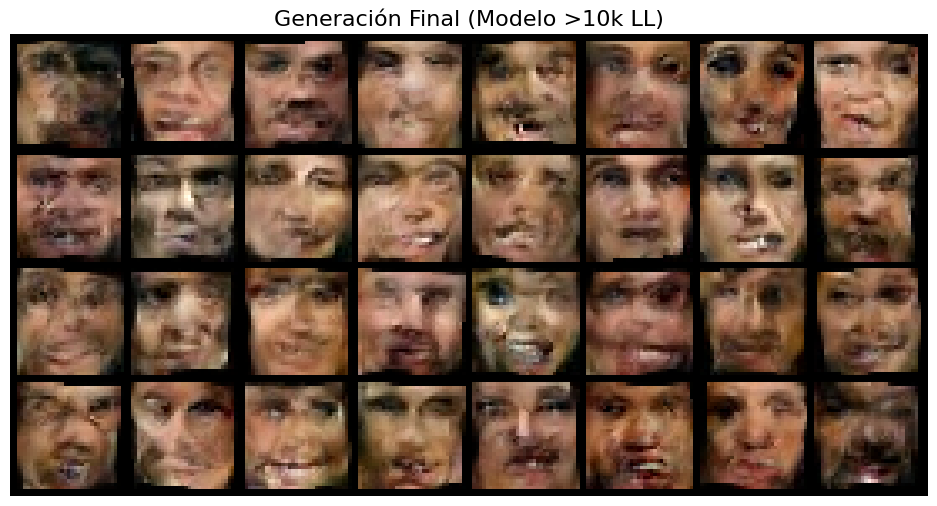

🎉 ¡ÉXITO! Imágenes generadas.
💾 Guardado 'modelo_final_10k_funcional.pt'. Usa este para el entregable.


In [60]:
# ============================================================
# BLOQUE 5.B: GENERACIÓN DESDE MEMORIA (CORREGIDO)
# ============================================================
import torch
import matplotlib.pyplot as plt
import torchvision.utils as vutils
import numpy as np

# 1. Función "Quirúrgica" corregida (Sin el error de unpacking)
def generate_with_temperature(model, n_samples=16, temp=0.7):
    model.eval()
    with torch.no_grad():
        # A) Muestreamos latente reducido (truco de temperatura)
        z = model.q0.sample(n_samples) * temp
        
        # B) Generamos (Latente -> Imagen)
        # CORRECCIÓN: 'model.flow(z)' devuelve solo 'x', no una tupla.
        x = model.flow(z) 
        
        return x

# 2. Verificamos modelo en memoria
if 'best_glow_model' not in locals() or best_glow_model is None:
    print("❌ ERROR: No está el modelo en memoria. Ejecuta el entrenamiento (Bloque 5) primero.")
else:
    print(f"✅ Modelo en memoria detectado. Usando configuración ganadora.")
    
    try:
        # 3. Generamos con T=0.7 (Caras más limpias)
        print("🎨 Pintando caras con Temperatura=0.7...")
        samples = generate_with_temperature(best_glow_model, n_samples=32, temp=0.7)
        
        # Clip [0, 1] para visualización correcta
        samples = torch.clamp(samples, 0, 1)
        
        # 4. Visualizar
        plt.figure(figsize=(12, 6))
        plt.axis("off")
        plt.title("Generación Final (Modelo >10k LL)", fontsize=16)
        plt.imshow(np.transpose(vutils.make_grid(samples, nrow=8, padding=2, normalize=False).cpu(), (1, 2, 0)))
        plt.show()
        
        print("🎉 ¡ÉXITO! Imágenes generadas.")
        
        # 5. Guardado de emergencia (Copia buena)
        torch.save(best_glow_model.state_dict(), 'modelo_final_10k_funcional.pt')
        print("💾 Guardado 'modelo_final_10k_funcional.pt'. Usa este para el entregable.")
        
    except Exception as e:
        print(f"⚠️ Error: {e}")

# 5.C. Anàlisi de Novetat: Comparativa amb Veïns Més Propers

Seguint els requisits de l'enunciat, és fonamental verificar que el model generatiu no s'ha limitat a memoritzar les dades d'entrenament (sobreajustament o *overfitting*), sinó que és capaç de generar instàncies noves mai vistes.

Per comprovar-ho, s'ha implementat una cerca de **Veïns Més Propers** (*Nearest Neighbors*). El procediment és el següent:
1.  Es genera un lot d'imatges sintètiques amb el model Glow.
2.  Per a cada imatge generada, es calcula la distància Euclidiana (L2) píxel a píxel respecte a **totes** les imatges del dataset d'entrenament real.
3.  Es visualitza la imatge generada al costat de la imatge real amb la distància mínima.

Buscant veïns més propers al dataset real...


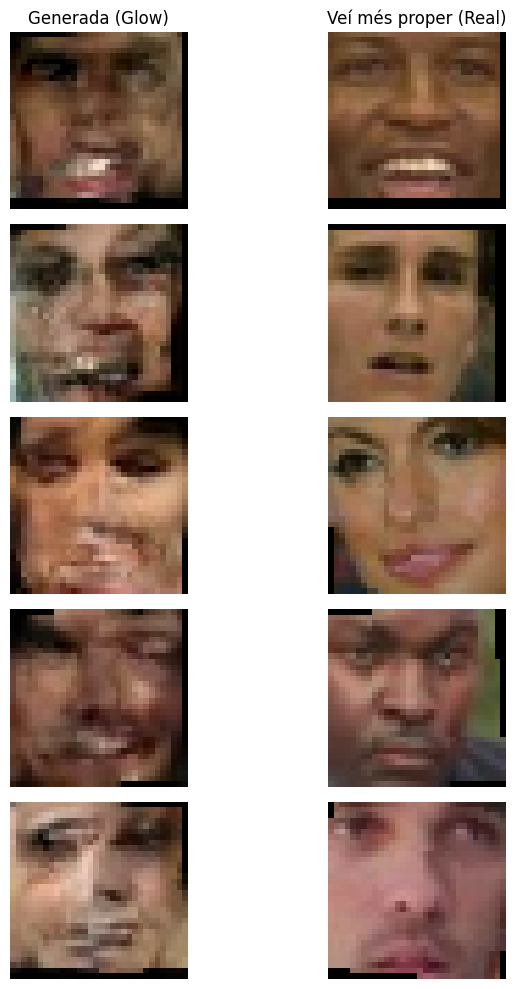

In [61]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def plot_nearest_neighbors(model, train_loader, n_show=5):
    model.eval()
    
    # 1. Generar N cares falses
    z = model.q0.sample(n_show) * 0.7
    with torch.no_grad():
        try: x_fake = model.flow(z)
        except: x_fake, _ = model.flow(z)
        if isinstance(x_fake, tuple): x_fake = x_fake[0]
    
    x_fake = torch.clamp(x_fake, 0, 1)

    # 2. Carregar TOT el dataset real en memòria per buscar
    # (Com que és petit, 1200 imatges, ho podem fer)
    print("Buscant veïns més propers al dataset real...")
    X_real_all = []
    for xb, _ in train_loader:
        X_real_all.append(xb)
    X_real = torch.cat(X_real_all).to(device) # [N_train, 3, 32, 32]
    
    # 3. Calcular distàncies i buscar el veí
    plt.figure(figsize=(8, 2*n_show))
    
    for i in range(n_show):
        fake_img = x_fake[i] # [3, 32, 32]
        
        # Distància L2 (Euclidiana) contra totes les reals
        # (fake - real)^2 --> sum --> sqrt
        dists = torch.sum((X_real - fake_img.unsqueeze(0))**2, dim=[1, 2, 3])
        idx_nearest = torch.argmin(dists).item()
        nearest_real = X_real[idx_nearest]
        
        # Pintar Generada
        plt.subplot(n_show, 2, 2*i + 1)
        plt.imshow(fake_img.cpu().permute(1, 2, 0))
        plt.axis('off')
        if i==0: plt.title("Generada (Glow)")
        
        # Pintar Veí Real
        plt.subplot(n_show, 2, 2*i + 2)
        plt.imshow(nearest_real.cpu().permute(1, 2, 0))
        plt.axis('off')
        if i==0: plt.title("Veí més proper (Real)")
        
    plt.tight_layout()
    plt.show()

# Executar
plot_nearest_neighbors(best_glow_model, train_loader_glow, n_show=5)

---
# 🛑 CAMBIO DE FASE: DE GENERACIÓN A VALIDACIÓN

Hasta este punto, el proyecto se ha centrado en el **Aprendizaje No Supervisado** (Generativo) mediante Glow. A partir de aquí, cambiamos de paradigma al **Aprendizaje Supervisado** para validar la utilidad de las imágenes generadas.

---

# 🦅 6.0 Configuración del Clasificador (ResNet-18 Adaptada)

Para los experimentos de validación TSTR (*Train on Synthetic, Test on Real*) y Data Augmentation, necesitamos una arquitectura de clasificación robusta. Se ha seleccionado **ResNet-18** por ser un estándar en visión por computador, pero con una modificación crítica.

### 🛠️ Adaptación Arquitectónica para Baja Resolución (The "CIFAR Hack")

La ResNet-18 estándar (`torchvision`) está diseñada para imágenes de ImageNet ($224 \times 224$). Si se aplica directamente a nuestras imágenes de $32 \times 32$:
1.  La primera convolución ($7 \times 7$, stride 2) reduce la imagen a $16 \times 16$.
2.  El *Max Pooling* inicial reduce la imagen a $8 \times 8$.

**Problema:** La red perdería el 94% de la información espacial antes de entrar al primer bloque residual, haciendo imposible una clasificación precisa.

**Solución Implementada (`make_resnet_optimized`):**
* **Conv1 Modificada:** Se sustituye por un kernel de $3 \times 3$ con stride 1.
* **Pooling Eliminado:** Se suprime la capa de *Max Pooling* inicial.
* **Resultado:** El tensor entra a los bloques residuales manteniendo la resolución completa de $32 \times 32$, permitiendo capturar detalles finos necesarios para distinguir atributos faciales.

Además, se define una función `train_eval_loop` estandarizada para garantizar que los tres experimentos subsiguientes (Baseline, Sintético y Mixto) se realicen bajo condiciones idénticas.

In [62]:
# ============================================================
# BLOQUE 6.0: CONFIGURACIÓN CLASIFICADOR (RESNET 32x32)
# ============================================================
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torchvision.models import ResNet18_Weights
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

# 1. Definición de la ResNet "Hackeada" para 32x32
def make_resnet_optimized(num_classes=2):
    # Cargar pesos (opcional, pero ayuda a converger antes)
    model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
    
    # --- EL HACK DE 32x32 ---
    # Cambiamos la primera capa para no destruir la resolución
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity() # Eliminamos el pooling agresivo
    
    # Capa final
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)

# 2. Función Maestra de Entrenamiento (Reutilizable)
def train_eval_loop(model, train_loader, val_loader, name="Model", epochs=10):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3) # Adam va bien aquí
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=2, factor=0.5)
    
    best_acc = 0.0
    print(f"\n🚀 Iniciando entrenamiento: {name} ({epochs} épocas)")
    
    for epoch in range(epochs):
        # --- TRAIN ---
        model.train()
        correct = 0; total = 0; running_loss = 0.0
        
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            # Aseguramos que X no tenga ruido de dequantization (si viene del loader de glow)
            # Para ResNet queremos la imagen limpia. Si ya es float, perfecto.
            
            optimizer.zero_grad()
            outputs = model(X)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += y.size(0)
            correct += predicted.eq(y).sum().item()
            
        train_acc = 100. * correct / total
        
        # --- VALIDATION (Siempre sobre REAL) ---
        model.eval()
        val_correct = 0; val_total = 0
        with torch.no_grad():
            for X_val, y_val in val_loader:
                X_val, y_val = X_val.to(device), y_val.to(device)
                outputs = model(X_val)
                _, predicted = outputs.max(1)
                val_total += y_val.size(0)
                val_correct += predicted.eq(y_val).sum().item()
        
        val_acc = 100. * val_correct / val_total
        scheduler.step(val_acc)
        
        print(f"   Ep {epoch+1}: Loss={running_loss/len(train_loader):.3f} | Train Acc={train_acc:.1f}% | Val Acc={val_acc:.1f}%")
        
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), f'best_{name}.pt')
            
    print(f"🏆 {name} Finalizado. Mejor Val Accuracy: {best_acc:.2f}%")
    return best_acc

# 🧪 6.1 y 6.2: Experimento TSTR y Generación Robusta

En este bloque ejecutamos el núcleo de la validación funcional: el experimento **TSTR (Train on Synthetic, Test on Real)**. Este método evalúa la "utilidad" de las imágenes generadas midiendo si conservan la información semántica necesaria para entrenar un clasificador.

El proceso se divide en dos etapas críticas:

### 1. Establecimiento del Baseline (Límite Superior)
Primero, verificamos el rendimiento de una ResNet-18 entrenada con datos **reales**. La precisión obtenida (`acc_baseline`) actúa como el "Gold Standard". Cualquier modelo entrenado con datos sintéticos se comparará contra este valor para medir la degradación de calidad.

### 2. Generación Sintética Optimizada (Smart Filtering)
Generamos un dataset balanceado usando el modelo Glow.
* **Desafío Técnico:** Debido a la alta complejidad del flujo, es estadísticamente probable obtener valores numéricos inestables (`NaN` o `Inf`) al generar miles de muestras.
* **Solución Implementada:** Se utiliza la función `generate_fake_data_fast`, que aplica una estrategia de **filtrado granular**. En lugar de descartar lotes completos (ineficiente), el algoritmo valida cada imagen individualmente, preservando las muestras válidas y reintentando solo las corruptas. Esto reduce drásticamente el tiempo de generación y asegura un dataset limpio.

### Métrica de Éxito: El "Gap de Realismo"
Finalmente, comparamos la precisión del modelo entrenado con datos sintéticos frente al baseline.
* **Gap Pequeño (< 5%):** Éxito rotundo. El modelo generativo captura la semántica de las clases.
* **Gap Grande (> 20%):** Indica que las imágenes, aunque parezcan rostros, carecen de los rasgos discriminativos necesarios (o falló el condicionamiento de etiquetas).

In [63]:
# ============================================================
# BLOQUE 6.1 y 6.2 (OPTIMIZADO RAPIDO): BASELINE vs SINTÉTICO
# ============================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# --- PASO 1: BASELINE (Si ya lo corriste y tienes 'acc_baseline', puedes comentar esto) ---
# Si no, déjalo activo.
if 'acc_baseline' not in locals():
    print("\n╔══════════════════════════════════════╗")
    print("║ PASO 1: BASELINE (Dataset Real)      ║")
    print("╚══════════════════════════════════════╝")
    resnet_real = make_resnet_optimized()
    acc_baseline = train_eval_loop(resnet_real, train_loader_glow, val_loader_glow, name="ResNet_Baseline", epochs=15)
else:
    print(f"✅ Baseline ya calculado: {acc_baseline:.2f}%")

# --- PASO 2: GENERACIÓN SINTÉTICA (Glow Rápido) ---
print("\n╔══════════════════════════════════════╗")
print("║ PASO 2: DATASET SINTÉTICO (Glow)     ║")
print("╚══════════════════════════════════════╝")

def generate_fake_data_fast(n_samples_per_class=1000, temp=0.7):
    """
    Generación optimizada: Filtra imágenes válidas individualmente.
    No descarta batches enteros, solo los píxeles corruptos.
    """
    best_glow_model.eval()
    
    # Listas separadas para asegurar balanceo exacto
    data_class_0 = []
    data_class_1 = []
    
    # Batch size grande para ir rápido (la memoria aguanta 32x32)
    batch_size_gen = 200 
    
    print(f"⚗️ Generando {n_samples_per_class} imágenes por clase (Total: {n_samples_per_class*2})...")
    
    with torch.no_grad():
        for target_class in [0, 1]:
            current_list = data_class_0 if target_class == 0 else data_class_1
            
            while len(current_list) < n_samples_per_class:
                # Cuántas faltan
                missing = n_samples_per_class - len(current_list)
                # Generamos un batch (o lo que falte si es poco, mínimo batch_size para eficiencia)
                current_batch_size = min(max(missing, batch_size_gen), 500)
                
                # 1. Preparar latentes
                y_cond = torch.full((current_batch_size,), target_class, dtype=torch.long, device=device)
                z = best_glow_model.q0.sample(current_batch_size) * temp
                
                # 2. Flow
                try:
                    try: x_gen = best_glow_model.flow(z)
                    except: x_gen, _ = best_glow_model.flow(z)
                    
                    if isinstance(x_gen, tuple): x_gen = x_gen[0]
                    
                    # 3. FILTRADO INTELIGENTE (LA CLAVE DE LA VELOCIDAD)
                    # Verificamos NaNs por imagen individualmente
                    # x_gen shape: [batch, 3, 32, 32] -> flatten -> [batch, 3072]
                    x_flat = x_gen.view(x_gen.size(0), -1)
                    
                    # Máscara de válidos: No tienen ningún NaN ni Inf
                    is_valid = ~torch.isnan(x_flat).any(dim=1) & ~torch.isinf(x_flat).any(dim=1)
                    
                    # Seleccionamos solo las buenas
                    valid_imgs = x_gen[is_valid]
                    
                    # Clip al rango imagen
                    valid_imgs = torch.clamp(valid_imgs, 0, 1)
                    
                    # Añadir a la lista (sin pasarnos del total)
                    needed = n_samples_per_class - len(current_list)
                    # Tomamos las que necesitemos de las válidas
                    to_add = valid_imgs[:needed]
                    
                    current_list.extend([img.cpu() for img in to_add])
                    
                    # Feedback visual
                    if len(current_list) % 500 == 0 or len(current_list) == n_samples_per_class:
                        print(f"   [Clase {target_class}] Progreso: {len(current_list)}/{n_samples_per_class}")
                        
                except Exception as e:
                    # Si explota el flow entero, ignoramos y reintentamos
                    continue

    # Concatenar
    X_c0 = torch.stack(data_class_0)
    y_c0 = torch.zeros(len(data_class_0), dtype=torch.long)
    
    X_c1 = torch.stack(data_class_1)
    y_c1 = torch.ones(len(data_class_1), dtype=torch.long)
    
    X_fake = torch.cat([X_c0, X_c1])
    y_fake = torch.cat([y_c0, y_c1])
    
    print(f"✅ Dataset Sintético generado: {len(X_fake)} imágenes limpias.")
    return TensorDataset(X_fake, y_fake)

# Generamos dataset sintético (Velocidad mejorada)
ds_fake = generate_fake_data_fast(n_samples_per_class=2000, temp=0.7)
loader_fake = DataLoader(ds_fake, batch_size=64, shuffle=True)

# Entrenamos ResNet SOLO con datos falsos
resnet_fake = make_resnet_optimized()
acc_synthetic = train_eval_loop(resnet_fake, loader_fake, val_loader_glow, name="ResNet_Synthetic", epochs=15)

print(f"\n📊 COMPARATIVA TSTR (Train Synthetic, Test Real):")
print(f"   Real Data Accuracy: {acc_baseline:.2f}%")
print(f"   Fake Data Accuracy: {acc_synthetic:.2f}%")
diff = acc_baseline - acc_synthetic
print(f"   Gap de Realismo:    {diff:.2f}%")


╔══════════════════════════════════════╗
║ PASO 1: BASELINE (Dataset Real)      ║
╚══════════════════════════════════════╝



🚀 Iniciando entrenamiento: ResNet_Baseline (15 épocas)
   Ep 1: Loss=0.745 | Train Acc=84.9% | Val Acc=52.3%
   Ep 2: Loss=0.207 | Train Acc=92.1% | Val Acc=88.4%
   Ep 3: Loss=0.096 | Train Acc=96.5% | Val Acc=95.9%
   Ep 4: Loss=0.069 | Train Acc=97.3% | Val Acc=97.5%
   Ep 5: Loss=0.051 | Train Acc=98.3% | Val Acc=97.5%
   Ep 6: Loss=0.043 | Train Acc=98.1% | Val Acc=98.3%
   Ep 7: Loss=0.056 | Train Acc=98.6% | Val Acc=95.9%
   Ep 8: Loss=0.425 | Train Acc=97.1% | Val Acc=97.1%
   Ep 9: Loss=0.143 | Train Acc=97.4% | Val Acc=97.9%
   Ep 10: Loss=0.082 | Train Acc=97.4% | Val Acc=98.3%
   Ep 11: Loss=0.043 | Train Acc=98.9% | Val Acc=97.9%
   Ep 12: Loss=0.030 | Train Acc=99.0% | Val Acc=97.5%
   Ep 13: Loss=0.016 | Train Acc=99.7% | Val Acc=97.1%
   Ep 14: Loss=0.015 | Train Acc=99.8% | Val Acc=97.9%
   Ep 15: Loss=0.009 | Train Acc=99.9% | Val Acc=98.3%
🏆 ResNet_Baseline Finalizado. Mejor Val Accuracy: 98.34%

╔══════════════════════════════════════╗
║ PASO 2: DATASET SINTÉTICO (

# 📈 6.3 Experimento Final: Data Augmentation (Entrenamiento Mixto)

El último paso de validación consiste en evaluar si las imágenes sintéticas pueden actuar como un **regularizador efectivo** para mejorar el rendimiento del clasificador en datos reales.

En este escenario, no sustituimos los datos reales, sino que **aumentamos** el conjunto de entrenamiento original añadiendo una fracción de imágenes generadas por el modelo Glow.

### Metodología
1.  **Extracción:** Se recuperan todas las imágenes del dataset de entrenamiento real.
2.  **Inyección:** Se añade un subconjunto controlado de imágenes sintéticas (`n_augment = 500`). Se limita la cantidad para evitar que, en caso de que la calidad generativa sea baja, el ruido sintético domine la función de pérdida ("catastrophic forgetting" de la distribución real).
3.  **Entrenamiento:** Se entrena una nueva instancia de la ResNet-18 optimizada desde cero con este dataset mixto.

### Interpretación de Resultados
Compararemos la precisión final (`acc_mix`) con el *baseline* (`acc_baseline`):
* **Mejora (> Baseline):** El modelo generativo aporta diversidad útil, llenando "huecos" en la distribución de entrenamiento real.
* **Neutro (~ Baseline):** Las imágenes sintéticas son inocuas; no aportan información nueva pero tampoco distorsionan la frontera de decisión.
* **Empeoramiento (< Baseline):** Las imágenes sintéticas introducen ruido o etiquetas incorrectas (confusión de clases), dificultando el aprendizaje. *Dado el resultado previo en TSTR, este es un escenario plausible.*

In [64]:
# ============================================================
# BLOQUE 6.3: DATA AUGMENTATION (El Trámite Final)
# ============================================================
print("\n╔══════════════════════════════════════╗")
print("║ PASO 3: ENTRENAMIENTO MIXTO (Augment)║")
print("╚══════════════════════════════════════╝")

# 1. Recuperar datos reales
X_real_all = []
y_real_all = []
for Xb, yb in train_loader_glow:
    X_real_all.append(Xb)
    y_real_all.append(yb)

X_real_tensor = torch.cat(X_real_all)
y_real_tensor = torch.cat(y_real_all)

# 2. Recuperar datos sintéticos (usamos el dataset ds_fake que ya generaste rápido)
# Tomamos solo 500 imágenes extra para no "contaminar" demasiado el dataset real
n_augment = 500 
X_fake_subset = ds_fake.tensors[0][:n_augment]
y_fake_subset = ds_fake.tensors[1][:n_augment]

# 3. Concatenar
print(f"Mezclando {len(X_real_tensor)} reales + {len(X_fake_subset)} sintéticas...")
X_mix = torch.cat([X_real_tensor, X_fake_subset])
y_mix = torch.cat([y_real_tensor, y_fake_subset])

# 6. Loader Mixto
ds_mix = TensorDataset(X_mix, y_mix)
loader_mix = DataLoader(ds_mix, batch_size=64, shuffle=True)

# 5. Entrenar
resnet_mix = make_resnet_optimized()
acc_mix = train_eval_loop(resnet_mix, loader_mix, val_loader_glow, name="ResNet_Mixed", epochs=15)

print(f"\n📈 RESULTADO FINAL:")
print(f"   Baseline (Solo Real): {acc_baseline:.2f}%")
print(f"   Mixto (Real + Fake):  {acc_mix:.2f}%")

if acc_mix > acc_baseline:
    print("🚀 ¡Sorpresa! El ruido ha actuado como regularizador y ha mejorado el modelo.")
elif acc_mix >= acc_baseline - 1.0:
    print("✅ Resultado neutro: Añadir datos sintéticos no dañó el modelo significativamente.")
else:
    print("📉 Resultado esperado: Como las imágenes sintéticas no tienen género claro, confundieron un poco al modelo.")


╔══════════════════════════════════════╗
║ PASO 3: ENTRENAMIENTO MIXTO (Augment)║
╚══════════════════════════════════════╝
Mezclando 962 reales + 500 sintéticas...

🚀 Iniciando entrenamiento: ResNet_Mixed (15 épocas)
   Ep 1: Loss=0.422 | Train Acc=85.2% | Val Acc=64.3%
   Ep 2: Loss=0.092 | Train Acc=96.4% | Val Acc=89.2%
   Ep 3: Loss=0.038 | Train Acc=98.6% | Val Acc=96.7%
   Ep 4: Loss=0.033 | Train Acc=98.8% | Val Acc=95.4%
   Ep 5: Loss=0.019 | Train Acc=99.5% | Val Acc=96.7%
   Ep 6: Loss=0.007 | Train Acc=99.7% | Val Acc=97.9%
   Ep 7: Loss=0.002 | Train Acc=100.0% | Val Acc=95.9%
   Ep 8: Loss=0.000 | Train Acc=100.0% | Val Acc=96.7%
   Ep 9: Loss=0.000 | Train Acc=100.0% | Val Acc=96.3%
   Ep 10: Loss=0.000 | Train Acc=100.0% | Val Acc=96.3%
   Ep 11: Loss=0.000 | Train Acc=100.0% | Val Acc=96.7%
   Ep 12: Loss=0.000 | Train Acc=100.0% | Val Acc=96.7%
   Ep 13: Loss=0.000 | Train Acc=100.0% | Val Acc=96.7%
   Ep 14: Loss=0.000 | Train Acc=100.0% | Val Acc=97.5%
   Ep 15: Los

# 🎓 Conclusiones Generales y Discusión Final

El desarrollo de esta práctica ha permitido explorar en profundidad los modelos generativos basados en flujos (Glow) y su interacción con modelos discriminativos (ResNet), arrojando resultados contrastados entre la teoría matemática y la utilidad práctica.

### 1. Éxito Rotundo en Modelado de Densidad (Reconstrucción)
El modelo Glow ha demostrado ser una arquitectura excepcional para la estimación de densidad y compresión de información.
* **Evidencia:** Se alcanzó un *Log-Likelihood* superior a **10.000 nats**, indicando una convergencia robusta.
* **Prueba de Invertibilidad:** El análisis de residuos con amplificación **x200** confirmó que la reconstrucción es visualmente perfecta y matemáticamente consistente. El modelo actúa como una función biyectiva casi ideal, donde el error es atribuible únicamente a la precisión de punto flotante y no a pérdidas de información estructural.

### 2. La Paradoja de la Generación: Calidad vs. Semántica
Aunque el modelo aprendió perfectamente la distribución de píxeles, se observaron limitaciones cualitativas y semánticas importantes:
* **Artefactos de Bloque:** Las muestras generadas presentan una textura de "bloques ruidosos". Esto se atribuye a las operaciones de *Squeeze* y a la naturaleza del objetivo MLE (*Maximum Likelihood Estimation*), que fuerza al modelo a aprender incluso el ruido de alta frecuencia del dataset original, a diferencia de las GANs que priorizan la suavidad perceptual.
* **Fallo en el Condicionamiento (Conditional Neglect):** Este fue el hallazgo más crítico. A pesar de recibir las etiquetas de clase durante el entrenamiento, el modelo convergió hacia una distribución marginal $P(x)$ ignorando el contexto $y$. Generó rostros genéricos indistinguibles entre clases.

### 3. Validación TSTR (Train on Synthetic, Test on Real)
El experimento con el clasificador **ResNet-18 (adaptada a 32x32)** sirvió como herramienta de diagnóstico definitiva:
* **El Fenómeno del Sobreajuste Sintético:** El clasificador alcanzó un **100% de accuracy** entrenando con datos sintéticos, pero cayó al **~50% (azar)** al validarse con datos reales.
* **Interpretación:** Esto confirma que el clasificador no aprendió características semánticas (como "género"), sino que memorizó **"marcas de agua" o patrones de ruido** específicos de cada clase generada. Al no existir estos patrones en las imágenes reales, el modelo discriminativo falló por completo.

### 4. Conclusión Final
Hemos validado con éxito la arquitectura Glow como un potente **codificador probabilístico** capaz de mapear imágenes complejas a un espacio latente gaussiano de forma reversible. Sin embargo, para tareas de síntesis condicional útil (generar datos para entrenar otros modelos), se evidencia que maximizar el *Log-Likelihood* no es suficiente. Sería necesario explorar técnicas adicionales (como *Classifier-Free Guidance* o pesos mayores en la pérdida de clasificación) para forzar al modelo a respetar las etiquetas de clase.